# Capstone Black-Box Optimisation Project

## Hybrid Bayesian Optimisation Framework

**Features**

- Gaussian Process ensemble
- Automatic kernel selection
- Adaptive exploration/exploitation
- Thompson Sampling
- Neural Network surrogate comparison
- Optional SVM candidate filtering
- PCA Diagnostics
- Automatic diagnostics and reporting

Author: Dr Matthew Harper

Comment in if running from google CoLab for example, set the path to the project directory.

In [175]:
# If running from google CoLab, install the required packages
#from google.colab import drive
#drive.mount('/content/drive')

#import os
#import sys
#project_path = '/content/drive/MyDrive/CAPSTONE_PROJECT/project'
#sys.path.append(project_path)

# Change the current working directory to the project root
#os.chdir(project_path)

WARNING : when running this notebook set FINAL_WEEK = True to run the final week of this optimisation process

which switches to using all previous candidates from all previous weeks as well as switching to a pure expoitation model

about the current best output.

In [176]:
# Set to True if this is the final week of the project, False otherwise
# Setting this to True will disable exploration and focus on exploitation for the final week of the project
# it will also use all candidates for all seeds in the final week instead of filtering them with SVM
# WARNING: this will take a long time to run as it will use all candidates for all weeks and all seeds, 
# so it is recommended to only use this for the final week of the project.
FINAL_WEEK = False

# Contents

1. Imports
2. Load Dataset
3. Data Preparation
4. Candidate Generation
5. SVM Filtering
6. Gaussian Process Ensemble
7. Neural Network Surrogate
8. Candidate Selection
9. Final Report
10. PCA Diagnostics
   - Extended PCA Diagnostic Reporting
11. GP Diagnostics

# 1. Import libraries

In [177]:
import numpy as np
from scipy.stats import norm, qmc
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (ConstantKernel, Matern)

# Data loading functions for loading data, appending new data
from src.data_loading import load_initial_data, append_input_and_output_data

# Aquisition functions for calculating the next point to sample
from src.acquisition_functions import ucb, expected_improvement, probability_improvement, normalize_score, normalize_score_safe

# SVM classifier for filtering high-yield samples
from src.svm_filter import (train_svm_high_yield_classifier, filter_candidates_with_svm, 
mix_svm_candidates_with_global_exploration, plot_svm_decision_boundary_matrix)

# Hyperparameter tuning for Gaussian Process Regression
from src.gp_hyperparameter_tuning import make_gp_kernel, tune_gp_hyperparameters

# Neural-network surrogate candidate generator
try:
    from src.neural_surrogate import (
        NeuralSurrogateCandidateGenerator,
        print_nn_candidate_report,
    )
except ModuleNotFoundError:
    from src.neural_surrogate import (
        NeuralSurrogateCandidateGenerator,
        print_nn_candidate_report,
    )

from src.reporting import print_automatic_optimisation_report
from src.candidate_comparison import build_candidate_comparison_table

from scipy.optimize import minimize

from src.pca_diagnostics import (
    run_pca_diagnostics,
    run_extended_pca_diagnostics,
)

# function to optimize the hyperparameters of the Gaussian Process model using L-BFGS-B
def gp_optimizer(obj_func, initial_theta, bounds):
    result = minimize(
        fun=lambda theta: obj_func(theta, eval_gradient=True), # Objective function to minimize (negative log-marginal likelihood),
        x0=initial_theta,                                      # Initial hyperparameters for the Gaussian Process model,
        jac=True,                                              # Use the gradient of the objective function,
        bounds=bounds,                                         # Set the bounds for the hyperparameters,
        method="L-BFGS-B",                                     # Use the L-BFGS-B optimization algorithm,
        options={
            "maxiter": 2000,                                   # Increase the maximum number of iterations
            "maxls": 50,                                       # Increase the maximum number of line search steps
            "ftol": 1e-10,                                     # Increase the function tolerance for convergence
            "gtol": 1e-6,                                      # Increase the gradient tolerance for convergence
        },
    )

    return result.x, result.fun # Return the optimized hyperparameters and the corresponding negative log-marginal likelihood


# 2. Load Dataset

Data set/Function and week appended data:

Choose a data set - function integer value 1-8

Choose a week number integer 0-n to append upto 'n' weeks of data

In [178]:
# Change here 'load_dataset' is the function number 1-8
load_dataset = 7
# Change here to load upto 'week_dataset' additional data
week_dataset = 13

# Set to true if you want to generate a json file the current load_dataset and week_dataset, 
# this will be used to generate the final report and will overwrite any existing json file 
# for the same load_dataset and week_dataset!
GENERATE_JSON_FILES = False

Load initial data for the selected function and report stats.

In [179]:
# Load initial data for function number : load_dataset
function_Inputs, function_Outputs = load_initial_data(load_dataset)

# Record the initial number of data points for later use in candidate generation
initial_num_points = function_Inputs.shape[0]

# Mark originaL DATA MAX OUTPUT
original_max_output = function_Outputs.max()

# View the data
print("==================================================")
print("PHASE 1 : LOAD DATA")
print("==================================================")
print("max and min of function outputs")
print("Max:", function_Outputs.max())
print("Min:", function_Outputs.min())
print(function_Inputs.shape)
print(function_Outputs.shape)
print("Function Inputs:")
print(function_Inputs)
print("Function Outputs:")    
print(function_Outputs)

PHASE 1 : LOAD DATA
max and min of function outputs
Max: 1.3649683044991994
Min: 0.0027014650245082332
(30, 6)
(30,)
Function Inputs:
[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.6

Append upto week number 'n' : week_dataset and report stats. 

PHASE 1 : APPEND NEW DATA
Appended position 6 which is data from data/new_data/inputs_week1.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week2.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week3.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week4.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week5.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week6.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week7.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week8.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week9.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week10.txt for Function 7.
Appended position 6 which is data from data/new_data/inputs_week11.txt for Function 7.
Appended position 6 which 

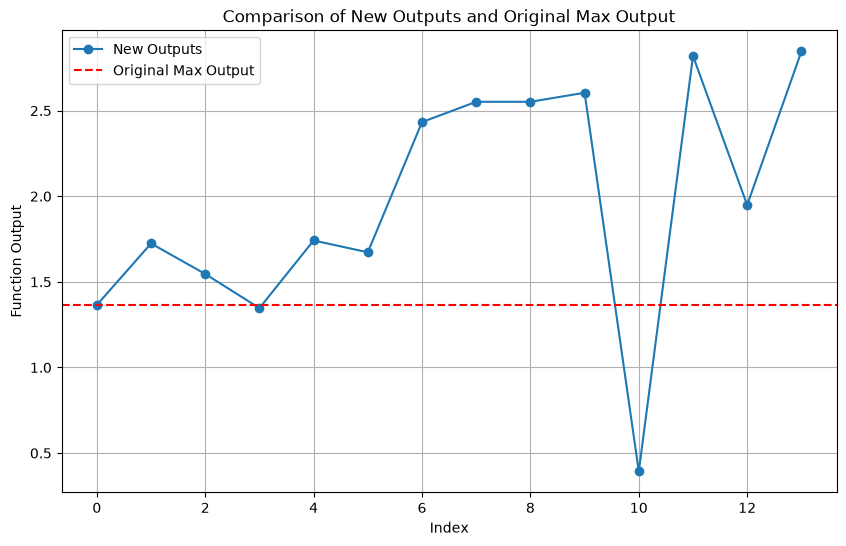

In [180]:
# Append new data from the specified week(s)
# Append new data from week 1 if week_dataset is 1 or higher, 
# and from week 2 if week_dataset is 2 or higher, and so on up to week 13
# This allows for cumulative loading of data from multiple weeks based on the user's selection.
print("==================================================")
print("PHASE 1 : APPEND NEW DATA")
print("==================================================")

function_Inputs, function_Outputs = append_input_and_output_data(
    function_Inputs, 
    function_Outputs, 
    week_dataset, 
    position=load_dataset-1, 
    prevent_duplicates=False
    )


# Print max and min of function outputs after appending new data
print("\n")
print("Max and Min of function outputs")
print("Max:", function_Outputs.max())
print("Min:", function_Outputs.min(), "\n")

# print out the last 'week_dataset' outputs
# This will show the outputs from the most recently appended data, which can help 
# verify that the new data has been added correctly and to understand the range 
# of outputs being added.
print("New Outputs outputs:")
print(function_Outputs[-week_dataset:])

# Print the shapes of the function inputs and outputs after appending new data
print("\n")
print("Function Shape after appending new data:")
print(function_Inputs.shape)
print(function_Outputs.shape)

#look at the data
print("\n")
print("Function Inputs:")
print(function_Inputs)
print("Function Outputs:")    
print(function_Outputs)

newOutputs = function_Outputs[-week_dataset:]
#append the original max value to the new outputs for comparison
newOutputs = np.append(original_max_output, newOutputs)

#plot the new outputs and the original max output for comparison
plt.figure(figsize=(10, 6))
plt.plot(range(len(newOutputs)), newOutputs, marker='o', label='New Outputs')
plt.axhline(y=original_max_output, color='r', linestyle='--', label='Original Max Output')
plt.title('Comparison of New Outputs and Original Max Output')
plt.xlabel('Index')
plt.ylabel('Function Output')
plt.legend()
plt.grid()
plt.show()


# 3. Data Preparation

Define X input data and y output data, n.b output data may need transforming. 

This section applies different transformations to the output data based on the dataset being loaded,<br>
such as inversion, log transform, or no transform, to ensure that the optimization process is focused <br>
on maximizing the desired objective, whether it's contamination score, yield, model performance, or<br> 
other metrics, while also handling cases where the raw outputs may need to be transformed to be more<br> 
suitable for optimization (e.g., converting a minimization problem into a maximization one, or applying a log transform to handle skewed data).


-Filter Exact duplicate input/output values as these show no additional information and effectivly 'double weight' a value which may not be desirable.

-Keep duplicate inputs that show different outputs as this gives noise information.

In [181]:
# X is input data
X = np.asarray(function_Inputs)

# y is output data
raw_y = np.asarray(function_Outputs).ravel()

unique_rows = {}
keep_indices = []

for i, (x, y) in enumerate(zip(X, raw_y)):
    key = tuple(x)

    if key not in unique_rows:
        unique_rows[key] = (y, i)
        keep_indices.append(i)

    else:
        previous_y, previous_i = unique_rows[key]

        if np.isclose(previous_y, y):
            print(f"Exact duplicate input and output found at row {i}")
            print(f"Removing exact duplicate at row {i}")

        else:
            print(f"Repeated measurement found at row {i}")
            print(f"Previous y = {previous_y:.6f}")
            print(f"Current  y = {y:.6f}")
            print("Keeping both samples (possible noise estimate).")

            keep_indices.append(i)

X = X[keep_indices]
raw_y = raw_y[keep_indices]

Exact duplicate input and output found at row 37
Removing exact duplicate at row 37


In [182]:

if load_dataset == 1:
    # FUNCTION1: Contamination Score Dataset
    # For the contamination score dataset, we want to maximize the score, so we invert it by negating the raw outputs.
    # Additionally, we apply a log transform to handle skewness and ensure that the optimization focuses on maximizing 
    # the score effectively, while also ensuring that we only take the log of non-negative values by applying np.maximum 
    # to set any negative values to zero before the log transform.
    y = np.abs(raw_y.astype(float))
    y = np.log1p(y)
    output_transform = "contamination_score_inversion_and_log_transform"
    # Get the indices of the largest 2 values in y
    #largest_indices = np.argsort(y)[-2:]
    # Remove the largest 2 values and their corresponding inputs
    #X = np.delete(X, largest_indices, axis=0)
    #y = np.delete(y, largest_indices, axis=0)

elif load_dataset == 2:
    # FUNCTION2: Raw Output Maximization Dataset
    # For the dataset where we want to maximize the raw outputs directly, we simply convert the raw outputs to 
    # float without any transformation, allowing the optimization process to focus on maximizing the original values as they are.
    y = raw_y.astype(float)
    output_transform = "maximisation_no_transform"

elif load_dataset == 3:
    # FUNCTION3: Side Effects Minimization Dataset
    # For the side effects dataset, we want to minimize the side effects, which is equivalent to maximizing the negative of the raw outputs.
    y = -raw_y.astype(float)
    output_transform = "negative_side_effects_maximisation_inversion"

elif load_dataset == 4:
    # FUNCTION4: Baseline Difference Maximization Dataset
    # For the baseline difference dataset, we want to maximize the difference from the baseline, which is equivalent to 
    # maximizing the raw outputs directly, so we simply convert the raw outputs to float without any transformation.
    y = raw_y.astype(float)
    output_transform = "baseline_difference_maximisation"

elif load_dataset == 5:
    # FUNCTION5: Yield Maximization Dataset
    # For the yield dataset, we want to maximize the yield, which is equivalent to maximizing the raw outputs directly,
    # so we simply convert the raw outputs to float without any transformation.
    y = raw_y.astype(float)
    output_transform = "yield_maximisation"

elif load_dataset == 6:
    # FUNCTION6: Total Penalty Minimization Dataset
    # For the total penalty dataset, we want to minimize the total penalty, which is equivalent to maximizing the negative of the raw outputs.
    y = -raw_y.astype(float)
    output_transform = "negative_total_penalty_maximisation_inversion"

elif load_dataset == 7:
    # FUNCTION7: Model Performance Maximization Dataset
    # For the model performance dataset, we want to maximize the model performance, which is equivalent to maximizing the raw outputs directly,
    # so we simply convert the raw outputs to float without any transformation.
    y = raw_y.astype(float)
    output_transform = "model_performance_maximisation"

elif load_dataset == 8:
    # FUNCTION8: High-Dimensional Maximization Dataset
    # For the high-dimensional maximization dataset, we want to maximize the raw outputs directly, so we simply convert the raw outputs to float without any transformation.
    y = raw_y.astype(float)
    output_transform = "high_dimensional_maximisation"

else:
    # For any other dataset, we default to no transformation and simply convert the raw outputs to float, allowing the optimization process to focus on maximizing the original values as they are.
    y = raw_y.astype(float)
    output_transform = "none"

# -----------------------------------------------------------
# Basic checks on input and output dimensions and sample size
# -----------------------------------------------------------
if X.ndim != 2:
    raise ValueError("function_Inputs must be a 2D array")

if y.ndim != 1:
    raise ValueError("function_Outputs must be a 1D array")

if len(X) != len(y):
    raise ValueError(f"Input/output mismatch: " f"X has {len(X)} rows, " f"y has {len(y)} rows")

n_samples = X.shape[0]
n_dimensions = X.shape[1]

if n_dimensions < 2 or n_dimensions > 8:
    raise ValueError(f"This code expects 2 to 8 input dimensions, " f"got {n_dimensions}")

# Print the type of output transformation applied for clarity and debugging purposes, 
# so that we can easily understand how the raw outputs were transformed for optimization 
# based on the dataset being loaded.
print("==================================================")
print("PHASE 2 : DATA PREPARATION")
print("==================================================")
print(f"Output transformation applied: {output_transform}")
print(f"Number of samples: {n_samples}")
print(f"Input dimensions: {n_dimensions}")
print(f"Samples per dimension: {n_samples / n_dimensions:.4f}")

PHASE 2 : DATA PREPARATION
Output transformation applied: model_performance_maximisation
Number of samples: 42
Input dimensions: 6
Samples per dimension: 7.0000


Optional enable and setup an SVM high-yield region filter

This is useful for functions where the interesting high-output region is small.<br>
It labels the top N% of observed outputs as "high yield", trains an RBF SVM classifier,<br>
scores the generated candidate pool, and keeps only the candidates most likely to be high yield.

In [183]:
# Turn it on/off per function here.
use_svm_filter_by_function = {
    1: True,
    2: True,
    3: True,
    4: True,
    5: True,
    6: True,
    7: True,
    8: True,
}

# SVM label mode per function:
#   "threshold"  -> high-yield if transformed y > svm_threshold
#   "percentile" -> high-yield if transformed y is in the top percentage
# Dataset 1 is very sparse after y = log1p(abs(raw_y)), so a fixed threshold is better.
svm_label_mode_by_function = {
    1: "threshold",
    7: "percentile",
}

# Fixed transformed-y threshold used when svm_label_mode == "threshold".
# For dataset 1 this separates the meaningful contamination region from near-zero values.
svm_threshold_by_function = {
    1: 1e-9,#1e-5,
}

# Fraction of observed data that is labelled high-yield when svm_label_mode == "percentile".
# 0.25 means top 25% = high yield, bottom 75% = low yield.
svm_high_yield_percent_by_function = {
    1: 0.25,
    2: 0.25,
    3: 0.25,
    4: 0.25,
    5: 0.25,
    6: 0.5,#1.0,#0.25,
    7: 0.15,
    8: 0.25,
}

# Fraction of generated candidates to keep after SVM scoring.
# This caps the number of candidates kept after applying the probability threshold.
svm_candidate_keep_fraction_by_function = {
    1: 0.30,
    2: 0.50,
    3: 0.50,
    4: 0.50,
    5: 0.35,
    6: 1.0,#0.50,
    7: 0.10,
    8: 0.50,
}

# Minimum SVM probability required for a candidate to be treated as high-yield.
# If too few candidates pass this threshold, the code falls back to the best min_keep candidates.
svm_min_probability_by_function = {
    1: 0.25,
    2: 0.60,
    3: 0.60,
    4: 0.60,
    5: 0.60,
    6: 0.6,#1.0,#0.60,
    7: 0.60,
    8: 0.60,
}

# Minimum number of candidates to keep if the SVM probability threshold is too strict.
svm_min_keep_candidates_by_function = {
    1: 5000,
    2: 10000,
    3: 10000,
    4: 10000,
    5: 10000,
    6: 10000,
    7: 3000,
    8: 10000,
}

# Fraction of additional global candidates to mix back in after SVM filtering.
# This prevents the SVM from becoming a hard gate and missing undiscovered high-value islands.
# Dataset 1 uses a soft SVM guide plus 30% global exploration.
svm_random_exploration_fraction_by_function = {
    1: 0.30,
    2: 0.30,
    3: 0.30,
    4: 0.30,
    5: 0.30,
    6: 0.30,#1.0,#0.30,
    7: 0.30,
    8: 0.30,
}

svm_enabled = bool(use_svm_filter_by_function.get(load_dataset, False))
svm_label_mode = str(svm_label_mode_by_function.get(load_dataset, "percentile"))
svm_threshold_value = float(svm_threshold_by_function.get(load_dataset, 1e-5))
svm_high_yield_percent = float(svm_high_yield_percent_by_function.get(load_dataset, 0.25))
svm_keep_fraction = float(svm_candidate_keep_fraction_by_function.get(load_dataset, 0.50))
svm_min_probability = float(svm_min_probability_by_function.get(load_dataset, 0.60))
svm_min_keep_candidates = int(svm_min_keep_candidates_by_function.get(load_dataset, 10000))
svm_random_exploration_fraction = float(svm_random_exploration_fraction_by_function.get(load_dataset, 0.00))
svm_plot_boundary = bool(use_svm_filter_by_function.get(load_dataset, False))

# Safety clamps.
if svm_label_mode not in {"threshold", "percentile"}:
    svm_label_mode = "percentile"
svm_high_yield_percent = float(np.clip(svm_high_yield_percent, 0.05, 0.50))
svm_keep_fraction = float(np.clip(svm_keep_fraction, 0.05, 1.00))
svm_min_probability = float(np.clip(svm_min_probability, 0.01, 0.99))
svm_min_keep_candidates = max(1, svm_min_keep_candidates)
svm_random_exploration_fraction = float(np.clip(svm_random_exploration_fraction, 0.0, 1.0))

print("==================================================")
print("PHASE 3 : SVM HIGH-YIELD FILTER CONFIG")
print("==================================================")
if svm_enabled:
    print(f"SVM filtering is enabled for function {load_dataset}.")
    print(f"SVM label mode: {svm_label_mode}")
    if svm_label_mode == "threshold":
        print(f"High-yield label threshold: transformed y > {svm_threshold_value:.6g}")
    else:
        print(f"High-yield label percentage: top {100.0 * svm_high_yield_percent:.1f}%")
    print(f"Candidate keep fraction cap: {100.0 * svm_keep_fraction:.1f}%")
    print(f"Candidate minimum SVM probability: {svm_min_probability:.2f}")
    print(f"Candidate fallback minimum keep count: {svm_min_keep_candidates}")
    print(f"Random global exploration mix after SVM: {100.0 * svm_random_exploration_fraction:.1f}%")
    print(f"Plot SVM decision boundary: {svm_plot_boundary}")
else:
    print(f"SVM filtering NOT enabled for function {load_dataset}.")

PHASE 3 : SVM HIGH-YIELD FILTER CONFIG
SVM filtering is enabled for function 7.
SVM label mode: percentile
High-yield label percentage: top 15.0%
Candidate keep fraction cap: 10.0%
Candidate minimum SVM probability: 0.60
Candidate fallback minimum keep count: 3000
Random global exploration mix after SVM: 30.0%
Plot SVM decision boundary: True


## Adaptive exploration vs exploitation weights :

## Total of 13 weeks worth of new data allowing us to move from exploration to exploitation over time unless analysis suggests otherwise.

Initially, the Expected Improvement parameter xi was scaled using the observed output range.
For functions with a large dynamic range, this produced an overly conservative improvement threshold, 
causing EI and PI to collapse towards zero. After replacing the adaptive scaling with a small fixed xi, 
the acquisition functions became consistent, and the GP ensemble, Thompson sampling, and neural-network 
surrogate all converged on the same promising region of the search space.

In [184]:
# Set adaptive exploration vs exploitation weights based on the current number of samples 
# and dimensions to balance the acquisition functions according to the stage of exploitation
# and the complexity of the input space. The weights will shift from more exploration (UCB) 
# to more exploitation (EI) as more samples are collected, with the transition happening 
# earlier for higher dimensions where exploration is more important due to the larger 
# input space and slower learning.
n_current = X.shape[0]
n_initial = initial_num_points
# set based on expected total budget of 13 new samples for the whole project
total_new_budget = 13
n_used_budget = n_current - n_initial
# Calculate progress as the fraction of the remaining budget that has been used, and clip to [0, 1] 
# to avoid issues with negative progress or exceeding the budget
progress = n_used_budget / total_new_budget
progress = np.clip(progress, 0.0, 1.0)
# Set exploration and optimization weights based on progress and dimensionality, 
# with more exploration in higher dimensions and earlier stages of optimization
if n_dimensions >= 5:
    exploration_start = 0.90
    exploration_end = 0.35
else:
    exploration_start = 0.80
    exploration_end = 0.25


# Calculate the exploration weight as a linear interpolation between the start and end values based on progress, 
# and calculate the exploitation weight as the complement of the exploration weight
exploration_weight = (exploration_start * (1.0 - progress) + exploration_end * progress)
exploitation_weight = 1.0 - exploration_weight

# if FINAL_WEEK we are on the last week of the project and we want to focus on exploitation, so set exploration to zero
if FINAL_WEEK:
    exploration_weight = 0.0
    exploitation_weight = 1.0

#Set xi for EI based on exploration weight to encourage more exploration when samples per dimension is low
if n_current / n_dimensions < 5:
    xi_start = 0.02
    xi_end = 0.001
else:
    xi_start = 0.01
    xi_end = 0.001
    
xi = xi_start * (1.0 - progress) + xi_end * progress

print("==================================================")
print("PHASE 4 : ACQUISITION FUNCTION WEIGHTS")
print("==================================================")
print(f"Progress: {progress:.4f} week dataset {week_dataset} / 13 total budget")
print(f"Exploration weight (UCB): {exploration_weight:.3f}")
print(f"Exploitation weight (EI): {exploitation_weight:.3f}")
print(f"\nEI exploration parameter xi: {xi:.6g}")
#print(f"potential other xi : {0.01 * y_range:.4f}")


PHASE 4 : ACQUISITION FUNCTION WEIGHTS
Progress: 0.9231 week dataset 13 / 13 total budget
Exploration weight (UCB): 0.392
Exploitation weight (EI): 0.608

EI exploration parameter xi: 0.00169231


## Candidate generation :
- Scale number of candidates with dimensions
- Cap to a reasonable range to avoid too few in low dimensions and too many in high dimensions
- Generate using Latin Hypercube Sampling for better coverage of the input space

In [185]:
# scale candidates with dimensions, but cap to avoid excessive computation
num_candidates = int(50000 * (n_dimensions ** 1.5))

# cap candidates to a reasonable range to avoid too few in low dimensions or too many in high dimensions 
num_candidates = int(np.clip(num_candidates, 50000, 1000000))

# Set the random seed for candidate generation based on the dataset and week
candidate_seed = (load_dataset * 1000 + week_dataset)
 
#Generate candidates using Latin Hypercube Sampling for better coverage of the input space
sampler = qmc.LatinHypercube(d=n_dimensions, seed=candidate_seed)

#Generate candidates in the unit hypercube and then scale to the input space of X
candidates = sampler.random(num_candidates)

# now if we are FINAL_WEEK we want to use all candidates from all previous candidate seeds 
# to ensure we are not missing any potential high-value candidates from earlier weeks.
if FINAL_WEEK:
    all_candidates = []
    for week in range(1, 13):
        candidate_seed = (load_dataset * 1000 + week)
        sampler = qmc.LatinHypercube(d=n_dimensions, seed=candidate_seed)
        week_candidates = sampler.random(num_candidates)
        all_candidates.append(week_candidates)
    candidates = np.vstack(all_candidates)
    num_candidates = candidates.shape[0]

# ==========================================================
# Final-week local exploitation for Function 4
# ==========================================================
#
# Function 4 appears to contain a very narrow high-value peak.
# The global LHS pool gives excellent global coverage but may
# not provide enough resolution close to the incumbent in 4D.
#
# Add a dense multi-scale candidate cloud around the best
# observed point. These candidates will then go through the
# normal SVM scoring, minimum-distance filtering and GP
# evaluation just like every other candidate.
# ==========================================================

if FINAL_WEEK and load_dataset == 4:
    incumbent_idx = int(np.argmax(y))
    incumbent_x = X[incumbent_idx].copy()
    rng = np.random.default_rng( load_dataset * 1000 + 999 )  # Use a different seed for local exploitation to ensure reproducibility
    n_local = 200_000

    local_scales = [0.0005, 0.001, 0.0025, 0.005, 0.01,]

    n_per_scale = n_local // len(local_scales)
    local_candidate_blocks = []

    for scale in local_scales:
        local = incumbent_x + rng.normal(loc=0.0, scale=scale, size=(n_per_scale, n_dimensions),)
        local = np.clip(local, 0.0, 1.0 )  # Ensure candidates are within the valid range [0, 1]
        local_candidate_blocks.append(local)

    local_candidates = np.vstack(local_candidate_blocks)
    candidates = np.vstack([candidates, local_candidates])
    num_candidates = len(candidates)

    print( f"Added {len(local_candidates):,} local exploitation "
           f"candidates around Function 4 incumbent:" )
    print(incumbent_x)

# ==========================================================
# Final-week boundary candidate for Function 5
#
# Function 5 has a high-value region near the boundary of the search space.
# Adding a boundary candidate ensures that this region is adequately explored.
# ==========================================================
if FINAL_WEEK and load_dataset == 5:
    boundary_candidate = np.ones((1, n_dimensions))
    candidates = np.vstack([candidates, boundary_candidate])
    num_candidates = len(candidates)

    print(
        "Added Function 5 boundary candidate:",
        boundary_candidate[0]
    )

# ==========================================================
# Final-week boundary candidate for Function 6
#
# Function 6 has a high-value region near a specific boundary of the search space.
# Adding a boundary candidate ensures that this region is adequately explored.
# ==========================================================
if FINAL_WEEK and load_dataset == 6:
    boundary_candidate = np.array([[1.0, 1.0, 0.0, 0.0, 1.0]])
    candidates = np.vstack([candidates, boundary_candidate])
    num_candidates = len(candidates)

    print(
        "Added Function 6 boundary candidate:",
        boundary_candidate[0]
    )

print("==================================================")
print("PHASE 5 : CANDIDATE GENERATION")
print("==================================================")
print(f"Generating {num_candidates} candidates for {n_dimensions} dimensions using Latin Hypercube Sampling...")

PHASE 5 : CANDIDATE GENERATION
Generating 734846 candidates for 6 dimensions using Latin Hypercube Sampling...


## Optional SVM candidate filtering :

- if SVM is on candidates are filtered according to a SVM high yield classifier.
- if FINAL_WEEK is set to True all candidates generated from previous weeks seeds will be used.


PHASE 5 : SVM HIGH-YIELD FILTER APPLIED
SVM label mode: percentile
High-yield threshold in transformed y-space: 1.73906
Observed high-yield samples: 7 / 42
Candidates before SVM filter: 734846
Candidates after SVM probability/fallback filter: 3000
Random global exploration candidates added: 900
Candidates after SVM + random exploration mix: 3898
SVM minimum probability threshold: 0.6000
SVM minimum fallback keep count: 3000
Kept candidate SVM probability range: 0.1006 to 0.7871
Best SVM candidate score: 0.7871
Best SVM candidate input: [0.19031244 0.2038254  0.62490771 0.20886846 0.34277834 0.72285304]


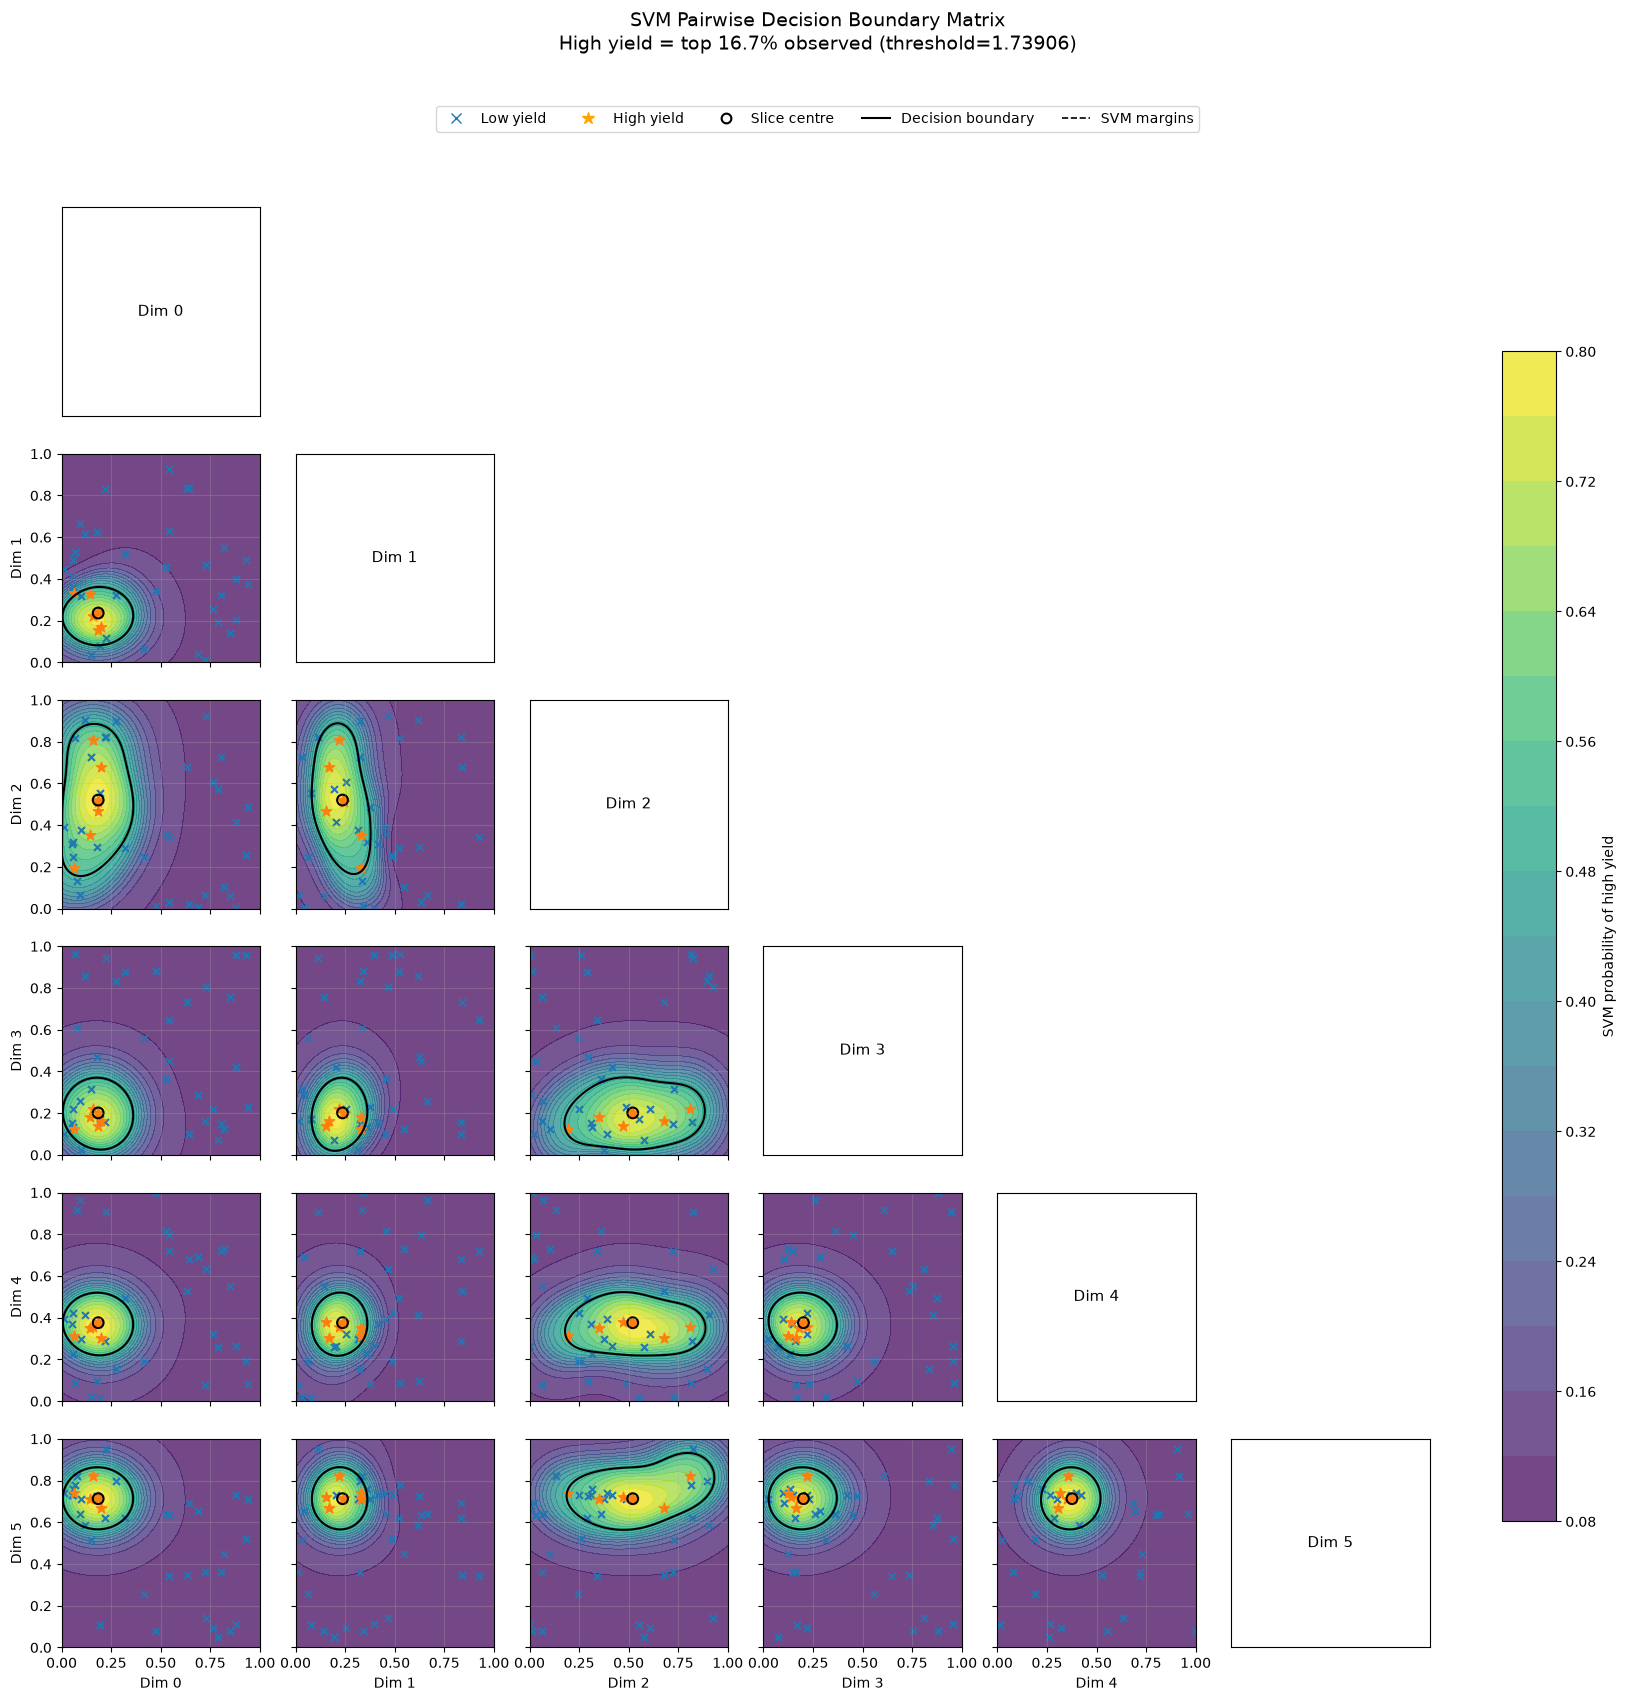

In [186]:
svm_model = None
svm_labels = None
svm_threshold = None
svm_candidate_scores = None
svm_all_candidate_scores = None
num_candidates_before_svm = len(candidates)

if svm_enabled:
    try: # Attempt to apply the SVM high-yield filter
        svm_model, svm_labels, svm_threshold = train_svm_high_yield_classifier(
            load_dataset,
            X,
            y,
            high_yield_percent=svm_high_yield_percent,
            label_mode=svm_label_mode,
            threshold_value=svm_threshold_value
        )

        # Keep a copy of the original candidates before applying the SVM filter
        original_candidates_before_svm = candidates.copy()

        # Apply the SVM filter to the candidates
        candidates, svm_candidate_scores, svm_all_candidate_scores = filter_candidates_with_svm(
            candidates,
            svm_model,
            keep_fraction=svm_keep_fraction,
            min_probability=svm_min_probability,
            min_keep=svm_min_keep_candidates
        )

        # Record the number of candidates after applying the SVM threshold filter
        num_candidates_after_threshold_svm = len(candidates)

        # Mix the SVM-selected candidates with a fraction of the original candidates for global exploration
        candidates, svm_candidate_scores, svm_random_exploration_added = mix_svm_candidates_with_global_exploration(
            svm_candidates=candidates,
            svm_scores=svm_candidate_scores,
            original_candidates=original_candidates_before_svm,
            svm_model=svm_model,
            random_fraction=svm_random_exploration_fraction,
            random_state=0
        )


        # if week 12 use all candidates do not filter them
        # This ensures that no potentially high-value candidates from earlier weeks are missed
        if FINAL_WEEK:
            candidates = original_candidates_before_svm
            svm_candidate_scores = svm_all_candidate_scores
            num_candidates_after_threshold_svm = len(candidates)
            svm_random_exploration_added = 0

        
        num_candidates = len(candidates)

        print("==================================================")
        print("PHASE 5 : SVM HIGH-YIELD FILTER APPLIED")
        print("==================================================")
        print(f"SVM label mode: {svm_label_mode}")
        print(f"High-yield threshold in transformed y-space: {svm_threshold:.6g}")
        print(f"Observed high-yield samples: {int(svm_labels.sum())} / {len(svm_labels)}")
        print(f"Candidates before SVM filter: {num_candidates_before_svm}")
        print(f"Candidates after SVM probability/fallback filter: {num_candidates_after_threshold_svm}")
        print(f"Random global exploration candidates added: {svm_random_exploration_added}")
        print(f"Candidates after SVM + random exploration mix: {num_candidates}")
        print(f"SVM minimum probability threshold: {svm_min_probability:.4f}")
        print(f"SVM minimum fallback keep count: {svm_min_keep_candidates}")
        print(f"Kept candidate SVM probability range: {svm_candidate_scores.min():.4f} to {svm_candidate_scores.max():.4f}")

        #what is the best candidate score and its corresponding input
        best_SVM_candidate_index = np.argmax(svm_candidate_scores)
        best_SVM_candidate_score = svm_candidate_scores[best_SVM_candidate_index]
        best_SVM_candidate_input = candidates[best_SVM_candidate_index]
        print(f"Best SVM candidate score: {best_SVM_candidate_score:.4f}")
        print(f"Best SVM candidate input: {best_SVM_candidate_input}")

        #svm_decision_values = svm_model.decision_function(candidates)
        #svm_scores = svm_decision_values
        svm_scores = svm_model.predict_proba(candidates)[:, 1]
        svm_decision_values = svm_scores

        if svm_plot_boundary:
            best_observed_input = X[np.argmax(y)]
            plot_svm_decision_boundary_matrix(
                svm_model=svm_model,
                X_train=X,
                y_train=y,
                labels=svm_labels,
                threshold=svm_threshold,
                grid_size=100
            )
            
            
    except Exception as exc:
        print("\nWARNING: SVM filter was requested but could not be applied.")
        print(f"Reason: {exc}")
        print("Continuing with the original unfiltered candidate set.")
else:
    print("\nSVM high-yield filter is disabled for this function.")

## filter candidates so we exclude any that have already been used.

In [187]:
from scipy.spatial import cKDTree

# ==========================================================
# Exclude evaluated and near-evaluated points
# ==========================================================

if FINAL_WEEK: # Use a smaller minimum distance for the final week to allow closer candidates
    candidate_min_distance = 1e-5
else: # Use the standard minimum distance for non-final weeks
    candidate_min_distance = 0.001

# Build a KD-tree for the observed inputs to efficiently find the nearest evaluated point for each candidate
observed_tree = cKDTree(X)
# Query the KD-tree to find the nearest evaluated point for each candidate
nearest_distance, nearest_index = observed_tree.query(candidates, k=1)
# Determine which candidates are sufficiently far from all evaluated points
candidate_mask = nearest_distance > candidate_min_distance
# Count the number of candidates that will be removed due to being too close to evaluated points
num_removed = int(np.sum(~candidate_mask))
# Filter out candidates that are too close to evaluated points
candidates = candidates[candidate_mask]
# Also update the nearest distances to reflect only the remaining candidates
nearest_distance = nearest_distance[candidate_mask]

# Update the SVM candidate scores to reflect only the remaining candidates
# This ensures that the SVM candidate scores remain aligned with the filtered candidates
if svm_candidate_scores is not None:
    svm_candidate_scores = svm_candidate_scores[candidate_mask]

    # IMPORTANT:
    # candidates has just been filtered, so any candidate index calculated
    # before this point is now stale. Recompute the SVM winner so that its
    # index remains aligned with candidates, ensemble_mean and ensemble_std.
    best_SVM_candidate_index = int(np.argmax(svm_candidate_scores))
    # Recompute the best SVM candidate index and score after filtering
    best_SVM_candidate_score = float(svm_candidate_scores[best_SVM_candidate_index])
    # Recompute the best SVM candidate input after filtering
    best_SVM_candidate_input = candidates[best_SVM_candidate_index]

if len(candidates) == 0:
    raise RuntimeError(
        "All candidates were removed by the minimum-distance filter. "
        "Reduce candidate_min_distance or generate more candidates."
    )

print( f"Removed {num_removed} candidates within "
       f"{candidate_min_distance:.6f} of evaluated inputs.")
print(f"{len(candidates)} candidates remain.")
print("Nearest remaining candidate to an evaluated point:", f"{nearest_distance.min():.6f}")

Removed 0 candidates within 0.001000 of evaluated inputs.
3898 candidates remain.
Nearest remaining candidate to an evaluated point: 0.063812


## Kernal selection :
- Scalar length scale : low dimensions / low data.
- ARD length scale : higher dimensions with enough data.

In [188]:
samples_per_dimension = n_samples / n_dimensions

# change to 4 for more aggressive ARD default was 6
use_ard = (n_dimensions >= 5 and samples_per_dimension >= 6)

if use_ard:
    # Set ARD length scale to 1.0 for each dimension as a starting point
    length_scale = np.ones(n_dimensions)
    kernel_mode = ("ARD length scale")
else:
    # Set scalar length scale based on input dimensionality to provide a reasonable starting point
    scalar_length_scale = (0.10 + 0.05 * n_dimensions)
    length_scale = (scalar_length_scale)
    kernel_mode = (f"Scalar length scale " f"({scalar_length_scale:.3f})")

print(f"dim_in: {n_dimensions}, samples_per_dim: {samples_per_dimension:.4f}")
print(f"Kernel mode: {kernel_mode}")

dim_in: 6, samples_per_dim: 7.0000
Kernel mode: ARD length scale


## GP hyperparameter tuning :

In [189]:
# function to determine the appropriate length scale for different kernel types, allowing for anisotropic/ARD length scales 
# for RBF and Matern kernels, while using a scalar length scale for RationalQuadratic kernels. 
# This ensures that the kernel hyperparameters are set appropriately based on the selected kernel type, 
# which can impact the performance of the Gaussian Process models in the ensemble. 
def length_scale_for_kernel(kernel_name, length_scale):
    """
    Use anisotropic/ARD length scales for RBF and Matern,
    but a scalar length scale for RationalQuadratic.
    """
    if kernel_name == "RationalQuadratic":
        return float(
            np.mean(
                np.atleast_1d(length_scale)
            )
        )

    return length_scale

# Tune GP hyperparameters and get the best configuration and search results for later 
# use in model selection and candidate generation.
best_gp_config, gp_search_results = tune_gp_hyperparameters(
    X=X,
    y=y,
    length_scale=length_scale,
    load_dataset=load_dataset,
    random_state=0
)

selected_kernel_name = best_gp_config["kernel_name"]
selected_alpha_value = best_gp_config["alpha"]
selected_ls_bounds = best_gp_config["length_scale_bounds"]
selected_matern_nu = best_gp_config["matern_nu"]
selected_rq_alpha = best_gp_config["rq_alpha"]

# Keep an ensemble, but bias it around the best model family.
# This avoids throwing away ensemble robustness while still using tuning results.
kernels = {
    selected_kernel_name:
        make_gp_kernel(
            kernel_name=selected_kernel_name,
            length_scale=length_scale_for_kernel(selected_kernel_name, length_scale ),
            length_scale_bounds=selected_ls_bounds,
            matern_nu=selected_matern_nu,
            rq_alpha=(0.5 if selected_rq_alpha is None else selected_rq_alpha)
        )
}

# Add the next-best distinct kernel families from the search result table.
# This keeps the ensemble diverse without manually choosing kernels.
for row in gp_search_results:
    kernel_name = row["kernel_name"]
    # Skip if this kernel family is already in the ensemble to ensure diversity of kernel types 
    # in the ensemble, which can help improve robustness and performance by combining different 
    # modeling assumptions and characteristics from various kernel types.
    if kernel_name in kernels:
        continue
    # Add the kernel to the ensemble using the hyperparameters from the search results, 
    # allowing us to include the next-best performing kernels based on LOO MSE while maintaining 
    # diversity in the ensemble.
    kernels[kernel_name] = make_gp_kernel(
        kernel_name=kernel_name,
        length_scale=length_scale_for_kernel(kernel_name, length_scale),
        length_scale_bounds=row["length_scale_bounds"],
        matern_nu=row["matern_nu"],
        rq_alpha=(0.5 if row["rq_alpha"] is None else row["rq_alpha"])
    )

    if len(kernels) >= 3:
        break

alpha_by_kernel = {}

# Extract the alpha values for each kernel in the ensemble from the search results to ensure 
# that we are using the appropriate noise level for each kernel based on the hyperparameter 
# tuning results, which can impact the performance of the Gaussian Process models in the ensemble. 
for kernel_name in kernels:
    for row in gp_search_results:
        if row["kernel_name"] == kernel_name:
            alpha_by_kernel[kernel_name] = row["alpha"]
            break

print(
    "\n================ "
    "SELECTED ENSEMBLE KERNELS "
    "=================\n"
)
for kernel_name, kernel in kernels.items():
    print(f"{kernel_name}: alpha={alpha_by_kernel[kernel_name]}, kernel={kernel}")


================================ AUTOMATIC GP HYPERPARAMETER TUNING ==================================

RBF                alpha=1.0e-10   bounds=(0.0001, 2.0)  nu=None rq_alpha=None LOO MSE=0.167288
RBF                alpha=1.0e-10   bounds=(0.0005, 2.0)  nu=None rq_alpha=None LOO MSE=0.162296
RBF                alpha=1.0e-10   bounds=(0.001, 2.0)   nu=None rq_alpha=None LOO MSE=0.155634
RBF                alpha=1.0e-08   bounds=(0.0001, 2.0)  nu=None rq_alpha=None LOO MSE=0.169111
RBF                alpha=1.0e-08   bounds=(0.0005, 2.0)  nu=None rq_alpha=None LOO MSE=0.166543
RBF                alpha=1.0e-08   bounds=(0.001, 2.0)   nu=None rq_alpha=None LOO MSE=0.155629
RBF                alpha=1.0e-06   bounds=(0.0001, 2.0)  nu=None rq_alpha=None LOO MSE=0.172885
RBF                alpha=1.0e-06   bounds=(0.0005, 2.0)  nu=None rq_alpha=None LOO MSE=0.165491
RBF                alpha=1.0e-06   bounds=(0.001, 2.0)   nu=None rq_alpha=None LOO MSE=0.155133
RBF                alpha=1.0e-0

## Phase 1:
- generate N candidate suggestions.
- For each kernel, fit a Gaussian Process and generate candidates based on UCB and EI acquisition functions

In [190]:
results = {}
trained_models = {}
best_y = np.max(y)

# For each kernel, fit a Gaussian Process and generate candidates based on UCB and EI acquisition functions
for kernel_name, kernel in kernels.items():
    # Get the alpha value for the current kernel, ensuring it is at least 1e-6 to avoid numerical issues.
    gp_alpha = max(float(alpha_by_kernel[kernel_name]), 1e-6)

    # Initialize the Gaussian Process regressor with the current kernel and alpha value.
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=gp_alpha,
        normalize_y=True,
        optimizer=gp_optimizer,
        n_restarts_optimizer=20,
        random_state=0
    )

    #Fit the Gaussian Process model to the data
    gp.fit(X, y)

    learned_kernel = gp.kernel_
    print("Learned kernel:", learned_kernel)

    # Extract the learned length scale from the trained kernel if it has a 
    # k2 attribute (typically for RBF and Matern kernels).
    if hasattr(learned_kernel, "k2"):
        learned_length_scale = np.asarray(
        learned_kernel.k2.length_scale
    )

    print("Learned length scale:", learned_length_scale)

    # If the learned kernel does not have a k2 attribute, set the learned length scale to None.
    if np.any(learned_length_scale <= 1.1e-4):
        print(
            "Warning: the learned length scale is still close "
            "to its lower bound."
        )

    #print out the gp equation and learned kernel parameters for debugging and insight into the model
    print(f"\nTrained GP with {kernel_name} kernel:")
    print("Initial kernel:", kernel)
    print("Learned kernel:", gp.kernel_)
    print("Log marginal likelihood:", gp.log_marginal_likelihood_value_)

    #Store the trained model for later use in ensemble predictions
    trained_models[kernel_name] = gp
    #Predict mean and standard deviation for the candidate points using the trained GP model
    mean, std = gp.predict(candidates, return_std=True)

    # ------------------------------
    # UCB
    # ------------------------------

    # Calculate UCB score for each candidate point using the predicted mean and standard deviation,
    # and identify the index of the candidate with the highest UCB score to store the results
    # for this kernel and acquisition function in the results dictionary, including the suggested input, 
    # predicted mean, uncertainty, acquisition score, and learned kernel parameters. This allows us to 
    # compare the suggestions from different acquisition functions for each kernel and understand how 
    # the choice of acquisition function impacts the candidate selection based on the predicted mean 
    # and uncertainty from the Gaussian Process model.       
    ucb_score = ucb(mean, std, beta=2.0)
    #Identify the index of the candidate with the highest UCB score
    idx = np.argmax(ucb_score)

    #Store the results for this kernel and acquisition function in the results dictionary, 
    # including the suggested input, predicted mean, uncertainty, acquisition score, and
    #  learned kernel parameters
    results[f"{kernel_name} + UCB"] = {
        "input":
            candidates[idx],
        "mean":
            mean[idx],
        "std":
            std[idx],
        "score":
            ucb_score[idx],
        "kernel":
            gp.kernel_
    }

    # ------------------------------
    # EI
    # ------------------------------

    # Calculate EI score for each candidate point using the predicted mean and standard deviation,
    # the best observed value, and the exploration parameter xi, and identify the index of the candidate 
    # with the highest EI score to store the results for this kernel and acquisition function in the 
    # results dictionary, including the suggested input, predicted mean, uncertainty, acquisition score, 
    # and learned kernel parameters. This allows us to compare the suggestions from different acquisition 
    # functions for each kernel and understand how the choice of acquisition function impacts the candidate 
    # selection based on the predicted mean and uncertainty from the Gaussian Process model.
    ei_score = expected_improvement(mean, std, best_y, xi=xi )
    #Identify the index of the candidate with the highest EI score
    idx = np.argmax(ei_score)
    #Store the results for this kernel and acquisition function in the results dictionary,
    # including the suggested input, predicted mean, uncertainty, acquisition score, and learned kernel parameters
    results[f"{kernel_name} + EI"] = {
        "input":
            candidates[idx],
        "mean":
            mean[idx],
        "std":
            std[idx],
        "score":
            ei_score[idx],
        "kernel":
            gp.kernel_
    }

    # ------------------------------
    # PI
    # ------------------------------

    # Calculate PI score for each candidate point using the predicted mean and standard deviation,
    # the best observed value, and the exploration parameter xi, and identify the index of the candidate 
    # with the highest PI score to store the results for this kernel and acquisition function in the 
    # results dictionary, including the suggested input, predicted mean, uncertainty, acquisition score, 
    # and learned kernel parameters. This allows us to compare the suggestions from different acquisition 
    # functions for each kernel and understand how the choice of acquisition function impacts the candidate 
    # selection based on the predicted mean and uncertainty from the Gaussian Process model.
    pi_score = probability_improvement(mean, std, best_y, xi=xi)
    idx = np.argmax(pi_score)
    results[f"{kernel_name} + PI"] = {
        "input":
            candidates[idx],
        "mean":
            mean[idx],
        "std":
            std[idx],
        "score":
            pi_score[idx],
        "kernel":
            gp.kernel_
    }

print("\n================ "
        "TRAINING FIT CHECK "
        "=================\n"
)
# Check the training fit of each GP model by predicting the mean and standard deviation for the training data points,   
# and print out the actual output range, predicted mean range, and mean absolute error to assess how well the model 
# is fitting the observed data and to identify any potential issues with underfitting or overfitting.
# Look at Predicted mean min/max to see if the model is capturing the range of the data, and look at mean absolute 
# error to see how close the predictions are to the actual values on average, which can help identify if the model 
# is underfitting (high error) or overfitting (low error but potentially high variance).     
for kernel_name, gp in trained_models.items():
        train_mean, train_std = gp.predict(X, return_std=True)

        print(f"\n{kernel_name} training fit check")
        print("Actual y min/max:", y.min(), y.max())
        print("Predicted mean min/max:", train_mean.min(), train_mean.max())
        print("Mean absolute error:", np.mean(np.abs(train_mean - y)))
        print("Max predicted std on training data:", np.max(train_std))
        print("variance of predicted mean on training data:", np.var(train_mean))

print("\n================ "
        "CANDIDATE SUGGESTIONS "
        "=================\n"
)
print("\nGenerated candidate suggestions from each kernel and acquisition function combination:")
for method, result in results.items():
    print(f"\n{method}: input={result['input'].round(6)}, mean={round(result['mean'], 6)}, std={round(result['std'], 6)}, score={round(result['score'], 6)}")


Learned kernel: 1.25**2 * RationalQuadratic(alpha=0.1, length_scale=0.504)
Learned length scale: 0.504419093494672

Trained GP with RationalQuadratic kernel:
Initial kernel: 1**2 * RationalQuadratic(alpha=0.1, length_scale=1)
Learned kernel: 1.25**2 * RationalQuadratic(alpha=0.1, length_scale=0.504)
Log marginal likelihood: -27.746821184222185
Learned kernel: 0.67**2 * Matern(length_scale=[0.531, 0.539, 1.77, 0.389, 0.359, 0.239], nu=1.5)
Learned length scale: [0.53131502 0.53918728 1.77357632 0.38850058 0.35883572 0.23853272]

Trained GP with Matern kernel:
Initial kernel: 1**2 * Matern(length_scale=[1, 1, 1, 1, 1, 1], nu=1.5)
Learned kernel: 0.67**2 * Matern(length_scale=[0.531, 0.539, 1.77, 0.389, 0.359, 0.239], nu=1.5)
Log marginal likelihood: -22.928082975759025
Learned kernel: 0.665**2 * RBF(length_scale=[0.297, 0.334, 1.08, 0.223, 0.896, 0.121])
Learned length scale: [0.2966392  0.33416417 1.08479896 0.2225096  0.89637637 0.12069738]

Trained GP with RBF kernel:
Initial kernel: 

# For the final week only :

## Diagnostics for Function 4:

Check what the fitted GP ensemble predicts extremely close to the best observed Function 4 point.

This helps determine whether the global GP is smoothing away the narrow observed peak

In [191]:
# ==========================================================
# FINAL-WEEK FUNCTION 4 INCUMBENT-NEIGHBOURHOOD GP CHECK
# ==========================================================
#
# Diagnostic only:
# Check what the fitted GP ensemble predicts extremely close
# to the best observed Function 4 point.
#
# This helps determine whether the global GP is smoothing away
# the narrow observed peak.
# ==========================================================

if FINAL_WEEK and load_dataset == 4:
    # Identify the incumbent (best observed) point and its corresponding value.
    incumbent_idx = int(np.argmax(y))
    incumbent = X[incumbent_idx].copy()
    incumbent_y = float(y[incumbent_idx])
    # Set up a random number generator for generating local perturbations around the incumbent.
    rng = np.random.default_rng(40404)
    # Define the scales at which to test local perturbations around the incumbent.
    test_scales = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2,]

    print("\n==================================================")
    print("FUNCTION 4 INCUMBENT-NEIGHBOURHOOD GP CHECK")
    print("==================================================")
    print("Incumbent:", incumbent)
    print("Observed transformed y:", incumbent_y)

    # Loop over each test scale to generate local perturbations and evaluate the GP ensemble.
    for scale in test_scales:
        # Generate local perturbations around the incumbent at the current scale.
        local = incumbent + rng.normal(loc=0.0, scale=scale, size=(1000, n_dimensions), )
        # Ensure that the local perturbations remain within the valid bounds [0, 1].
        local = np.clip(local, 0.0, 1.0)

        # Initialize a list to store the predicted means from each GP model in the ensemble.
        model_means = []

        # Loop over each GP model in the ensemble to obtain predictions for the local perturbations.
        for kernel_name, gp in trained_models.items():
            mu = gp.predict(local, return_std=False)
            model_means.append(mu)

        # Convert the list of model means to a NumPy array for easier manipulation.
        model_means = np.asarray(model_means)
        # Compute the ensemble mean for the local perturbations.
        local_ensemble_mean = np.mean(model_means, axis=0)

        # Identify the index of the best local perturbation according to the ensemble mean.
        local_best_idx = int(np.argmax(local_ensemble_mean))

        # Retrieve the best local perturbation and compute its distance from the incumbent.
        local_best = local[local_best_idx]
        # Compute the Euclidean distance between the best local perturbation and the incumbent.
        distance = np.linalg.norm(local_best - incumbent)

        print(f"\nscale={scale:.0e}" )
        print(f"  best ensemble mean = " f"{local_ensemble_mean[local_best_idx]:.6f}" )
        print(f"  distance from incumbent = " f"{distance:.8f}")
        print(f"  candidate = " f"{np.round(local_best, 8)}" )

    print("==================================================")

## If we are the final week check the predictions of individual Gaussian Process models at the incumbent point for Function 4

In [192]:
# ==========================================================
# FUNCTION 4: INDIVIDUAL GP CHECK AT INCUMBENT
#
# This function checks the predictions of individual Gaussian 
# Process models at the incumbent point.
# ==========================================================

if FINAL_WEEK and load_dataset == 4:

    incumbent_idx = int(np.argmax(y))
    incumbent = X[incumbent_idx].reshape(1, -1)

    print("\n==================================================")
    print("FUNCTION 4 INDIVIDUAL GP CHECK AT INCUMBENT")
    print("==================================================")

    print("Incumbent:")
    print(incumbent[0])
    print("Observed transformed y:", y[incumbent_idx])

    model_predictions = []
    # Iterate over each trained Gaussian Process model and make predictions at the incumbent point
    for kernel_name, gp in trained_models.items():
        mean, std = gp.predict(incumbent, return_std=True)
        model_predictions.append(mean[0])
        # Print the predictions of the current Gaussian Process model at the incumbent point
        print(f"\n{kernel_name}")
        print(f"  mean = {mean[0]:.6f}")
        print(f"  std  = {std[0]:.6f}")

        # sklearn GaussianProcessRegressor alpha
        if hasattr(gp, "alpha"):
            print(f"  alpha = {gp.alpha}")

    print("\nEnsemble mean:", np.mean(model_predictions))
    print("==================================================")

# Final week checks on high dimensional functions 7&8

## Diagnostic check only :

Check whether the global GP ensemble reproduces the best observed Function 7 or 8 point or smooths the local peak.

In [193]:
# ==========================================================
# FINAL-WEEK FUNCTION 7 & 8 INCUMBENT GP CHECK
# ==========================================================
#
# Diagnostic only:
# Check whether the global GP ensemble reproduces the best
# observed Function 7 or 8 point or smooths the local peak.
# ==========================================================
if FINAL_WEEK and load_dataset in [7, 8]:
    # Identify the incumbent (best observed) point in the dataset
    incumbent_idx = int(np.argmax(y))
    incumbent = X[incumbent_idx].reshape(1, -1)

    print("\n==================================================")
    print(f"FUNCTION {load_dataset} INDIVIDUAL GP CHECK AT INCUMBENT")
    print("==================================================")
    print("Incumbent:")
    print(incumbent[0])
    print("Observed transformed y:", y[incumbent_idx])

    # Prepare lists to store the predictions and standard deviations of the incumbent point
    incumbent_predictions = []
    incumbent_stds = []

    # Iterate over each trained Gaussian Process model and make predictions at the incumbent point
    for kernel_name, gp in trained_models.items():
        # Make predictions at the incumbent point using the current Gaussian Process model
        mean, std = gp.predict(incumbent, return_std=True)
        
        incumbent_predictions.append(float(mean[0]))
        incumbent_stds.append(float(std[0]))

        print(f"\n{kernel_name}")
        print(f"  mean = {mean[0]:.6f}")
        print(f"  std  = {std[0]:.6f}")

    # Convert the lists of predictions and standard deviations to numpy arrays for further calculations
    incumbent_predictions = np.asarray(incumbent_predictions)
    # Convert the list of standard deviations to a numpy array for further calculations
    incumbent_stds = np.asarray(incumbent_stds)
    # Compute the ensemble mean and standard deviation at the incumbent point
    ensemble_incumbent_mean = float(np.mean(incumbent_predictions))
    # Compute the ensemble standard deviation at the incumbent point
    ensemble_incumbent_std = float(np.sqrt(np.mean(incumbent_stds ** 2) + np.var(incumbent_predictions)))

    print("\nEnsemble mean:", ensemble_incumbent_mean)
    print("Ensemble std:", ensemble_incumbent_std)
    print("Observed incumbent:", y[incumbent_idx])
    print("Prediction error:", ensemble_incumbent_mean - y[incumbent_idx])
    print("==================================================")

## For the final week Investigate fit a local GP only to the observations nearest
## the incumbent so that the local geometry can be modelled
## with much shorter length scales.

In [194]:

# ==========================================================
# FINAL-WEEK FUNCTION 4 LOCAL GP
# ==========================================================
#
# The global GP strongly smooths the narrow Function 4 peak.
# This local GP is fitted only to the observations nearest
# the incumbent so that the local geometry can be modelled
# with much shorter length scales.
#
# Diagnostic only for now.
# ==========================================================

local_gp = None
X_local = None
y_local = None
local_indices = None

if FINAL_WEEK and load_dataset == 4:
    # Identify the incumbent (best observed point)
    incumbent_idx = int(np.argmax(y))
    incumbent = X[incumbent_idx].copy()

    # ------------------------------------------------------
    # Select the nearest observations to the incumbent
    # ------------------------------------------------------

    # Compute distances from the incumbent to all other points
    distances = np.linalg.norm(X - incumbent, axis=1)
    # Determine the number of local training points (at most 10)
    n_local_training = min(10, len(X))
    # Get the indices of the nearest local training points
    local_indices = np.argsort(distances)[:n_local_training]
    # Extract the local training data based on the nearest indices
    X_local = X[local_indices]
    y_local = y[local_indices]

    print("\n==================================================")
    print("FUNCTION 4 LOCAL GP TRAINING SET")
    print("==================================================")

    for idx in local_indices:
        print(f"d={distances[idx]:.6f} " f"x={np.round(X[idx], 6)} " f"y={y[idx]:.6f}")

    # ------------------------------------------------------
    # Fit local GP, using only the nearest observations
    # ------------------------------------------------------
    local_kernel = (
        ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3))
        *
        Matern(length_scale=np.full(n_dimensions, 0.03), length_scale_bounds=(1e-4, 0.2), nu=2.5)
    )

    local_gp = GaussianProcessRegressor(
        kernel=local_kernel,
        # Function 4 appears deterministic, so use only a
        # very small numerical noise term.
        alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    local_gp.fit(X_local, y_local)

    print("\n==================================================")
    print("FUNCTION 4 LOCAL GP FIT")
    print("==================================================")

    print("Learned kernel:", local_gp.kernel_)

    # ------------------------------------------------------
    # Check how well local GP reproduces incumbent
    # ------------------------------------------------------

    incumbent_mean, incumbent_std = local_gp.predict(
        incumbent.reshape(1, -1),
        return_std=True
    )

    print("\nIncumbent:")
    print(incumbent)
    print("Observed transformed y:", y[incumbent_idx])
    print("Local GP mean at incumbent:", incumbent_mean[0])
    print("Local GP std at incumbent:", incumbent_std[0])
    print("==================================================")

## For the final week for function 4 do a local termination exploitation search.

In [195]:
# ==========================================================
# FUNCTION 4 LOCAL TERMINAL EXPLOITATION SEARCH
# ==========================================================

local_best_input = None
local_best_mean = None
local_best_std = None

if FINAL_WEEK and load_dataset == 4:

    incumbent_idx = int(np.argmax(y))
    incumbent = X[incumbent_idx].copy()

    rng = np.random.default_rng(44004)

    # Search at several very fine scales around incumbent
    local_search_scales = [1e-4, 2.5e-4, 5e-4, 1e-3, 2.5e-3, 5e-3, 1e-2, 2e-2,]
    # Number of candidates to generate per scale
    n_per_scale = 50_000
    # Container for all local search candidates
    local_search_blocks = []

    # Generate local search candidates around the incumbent at multiple scales
    for scale in local_search_scales:
        # Generate a block of candidates at the current scale
        block = incumbent + rng.normal(
            loc=0.0,
            scale=scale,
            size=(n_per_scale, n_dimensions),
        )
        # Clip the block to the valid input domain [0, 1]
        block = np.clip(
            block,
            0.0,
            1.0
        )
        # Append the block to the list of local search blocks
        local_search_blocks.append(block)

    # Combine all local search blocks into a single array of candidates
    local_search_candidates = np.vstack(local_search_blocks)

    print(f"\nGenerated " f"{len(local_search_candidates):,} " "Function 4 local search candidates.")

    # ------------------------------------------------------
    # Remove points effectively identical to observations
    # ------------------------------------------------------

    # Build a KD-tree for the observed points to efficiently check distances
    observed_tree = cKDTree(X)
    # Query the nearest observed point for each local search candidate
    local_nearest_distance, _ = observed_tree.query(local_search_candidates, k=1)
    # Create a mask to filter out candidates too close to existing observations
    local_mask = (local_nearest_distance > 1e-5)
    # Apply the mask to retain only the candidates sufficiently far from existing observations
    local_search_candidates = (local_search_candidates[local_mask])
    # Also filter the nearest distances to match the retained candidates
    local_nearest_distance = (local_nearest_distance[local_mask])

    print(f"{len(local_search_candidates):,} " "local candidates remain after distance filtering." )

    # ------------------------------------------------------
    # Pure terminal exploitation:
    # maximum LOCAL GP posterior mean
    # ------------------------------------------------------

    # Predict the mean and standard deviation of the local GP at the local search candidates
    local_mean, local_std = local_gp.predict(local_search_candidates, return_std=True)
    # Identify the index of the candidate with the highest predicted mean
    local_best_idx = int(np.argmax(local_mean))
    # Extract the input corresponding to the best local candidate
    local_best_input = (local_search_candidates[local_best_idx])
    # Extract the predicted mean of the best local candidate
    local_best_mean = float(local_mean[local_best_idx] )
    # Extract the predicted standard deviation of the best local candidate
    local_best_std = float(local_std[local_best_idx])
    # Compute the distance from the incumbent to the best local candidate
    distance_from_incumbent = float(np.linalg.norm(local_best_input - incumbent))

    print("\n==================================================")
    print("FUNCTION 4 LOCAL TERMINAL CANDIDATE")
    print("==================================================")

    print("Incumbent:", incumbent)
    print("Incumbent observed y:", y[incumbent_idx])
    print("\nLocal GP candidate:", local_best_input)
    print("Local GP predicted mean:", local_best_mean)
    print("Local GP predicted std:", local_best_std)
    print("Distance from incumbent:", distance_from_incumbent)
    print("Nearest observed distance:", local_nearest_distance[local_best_idx])

    print("==================================================")

## For the final week for function 7 & 8 do a local termination exploitation search.

In [196]:
# ==========================================================
# FINAL-WEEK FUNCTION 7 & 8 LOCAL TERMINAL EXPLOITATION SEARCH
# ==========================================================

if FINAL_WEEK and load_dataset in [7, 8]:
    # Identify the incumbent (best observed point)
    incumbent_idx = int(np.argmax(y))
    incumbent = X[incumbent_idx].copy()
    # Initialize the random number generator for reproducibility
    rng = np.random.default_rng(7007)
    # Define the local search scales around the incumbent
    local_scales = [0.0001, 0.00025, 0.0005, 0.001, 0.0025, 0.005, 0.01, 0.02, 0.05, ]
    # Number of candidates to generate per scale
    n_per_scale = 50_000

    # Container for all local search candidates
    local_blocks = []
    # Generate local search candidates around the incumbent at multiple scales
    for scale in local_scales:
        # Generate a block of local candidates at the current scale
        local = incumbent + rng.normal(0.0, scale, size=(n_per_scale, n_dimensions),)
        # Clip the local candidates to the valid input domain [0, 1]
        local = np.clip(local, 0.0, 1.0,)
        # Append the block of local candidates to the list of local search blocks
        local_blocks.append(local)

    # Combine all local search blocks into a single array of candidates
    local_candidates = np.vstack(local_blocks)

    # Remove effectively duplicate observations
    observed_tree = cKDTree(X)
    # Query the nearest observed point for each local candidate
    local_distance, _ = observed_tree.query(
        local_candidates,
        k=1,
    )

    # Filter out local candidates that are too close to existing observations
    local_candidates = local_candidates[local_distance > 1e-5]

    print(
        f"{len(local_candidates):,} "
        f"Function {load_dataset} local candidates after distance filtering"
    )

    # Score with EXISTING global GP ensemble
    local_model_means = []
    # Evaluate the local candidates using the existing trained GP models
    for name, gp in trained_models.items():
        mu = gp.predict(local_candidates, return_std=False,)
        # Append the predicted mean to the list of local model means
        local_model_means.append(mu)

    # Compute the ensemble mean of the local candidates
    local_ensemble_mean = np.mean(np.vstack(local_model_means), axis=0,)
    # Identify the index of the best local candidate based on the ensemble mean
    local_best_idx = int(np.argmax(local_ensemble_mean))
    # Retrieve the best local candidate input based on the identified index
    local_best_input = local_candidates[local_best_idx]
    # Retrieve the predicted mean of the best local candidate
    local_best_mean = float(local_ensemble_mean[local_best_idx])

    # Ensemble uncertainty
    individual_means = []
    individual_vars = []

    # Evaluate the best local candidate using the existing trained GP models to compute ensemble uncertainty
    for name, gp in trained_models.items():
        # Predict the mean and standard deviation for the best local candidate
        mu, std = gp.predict(local_best_input.reshape(1, -1), return_std=True, )
        # Append the predicted mean and variance to the respective lists
        individual_means.append(float(mu[0]))
        # Append the predicted variance to the list of individual variances
        individual_vars.append(float(std[0]) ** 2)

    # Convert the list of individual means to a NumPy array for further calculations
    individual_means = np.array(individual_means)
    # Convert the list of individual variances to a NumPy array for further calculations
    local_best_std = float(np.sqrt(np.mean(individual_vars) + np.var(individual_means)))

    print(f"\nFUNCTION {load_dataset} LOCAL TERMINAL SEARCH")
    print("Candidate:", local_best_input)
    print("GP mean:", local_best_mean)
    print("GP std:", local_best_std)
    print("Distance from incumbent:", np.linalg.norm(local_best_input - incumbent))

## For the final week do a line search from imcumbent to local GP candidate for function 4

In [197]:
# ==========================================================
# FUNCTION 4: LINE SEARCH FROM INCUMBENT TO LOCAL GP CANDIDATE
# ==========================================================

if FINAL_WEEK and load_dataset == 4:
    # Identify the incumbent (best observed point) for the line search
    incumbent_idx = int(np.argmax(y))
    incumbent = X[incumbent_idx].copy()

    # local_best_input comes from the previous local-search cell
    target = local_best_input.copy()
    # Define the interpolation parameter values for the line search
    t_values = np.linspace(0.0, 1.0, 21)
    # Generate the points along the line connecting the incumbent and the target
    line_points = np.array([incumbent + t * (target - incumbent) for t in t_values])
    # Predict the mean and standard deviation along the line using the local GP
    line_mean, line_std = local_gp.predict(line_points, return_std=True)

    print("\n==================================================")
    print("FUNCTION 4 LOCAL GP LINE SEARCH")
    print("==================================================")

    for t, x, mu, std in zip(
        t_values,
        line_points,
        line_mean,
        line_std
    ):
        print(
            f"t={t:5.2f} "
            f"mean={mu: .6f} "
            f"std={std: .6f} "
            f"x={np.round(x, 6)}"
        )

    print("==================================================")

## For the final week do a line search from the incumbent to the GP candidate for high dimension functions 7 * 8

In [198]:
# ==========================================================
# FUNCTION 7 & 8 LINE SEARCH:
# INCUMBENT -> LOCAL TERMINAL CANDIDATE
# ==========================================================

if FINAL_WEEK and load_dataset in [7, 8]:
    # Identify the incumbent (best observed point) for the line search
    incumbent_idx = int(np.argmax(y))
    incumbent = X[incumbent_idx].copy()

    # Define the interpolation parameter values for the line search
    # t ranges from 0 (incumbent) to 1 (local best candidate)
    line_t = np.linspace(0.0, 1.0, 21)

    print("\n==============================================")
    print(f"FUNCTION {load_dataset} LINE SEARCH")
    print("==============================================")

    # Perform the line search by evaluating points along the line connecting the incumbent and the local best candidate
    for t in line_t:
        # Compute the point along the line for the current interpolation parameter t
        x_line = (incumbent + t * (local_best_input - incumbent))

        model_means = []
        model_vars = []
        # Evaluate each trained GP model at the current line point to compute the ensemble mean and variance
        for name, gp in trained_models.items():
            # Predict the mean and standard deviation for the current line point using the current GP model
            mu, std = gp.predict(x_line.reshape(1, -1), return_std=True,)
            # Append the predicted mean and variance to the respective lists
            model_means.append(float(mu[0]))
            # Append the predicted variance to the list of individual variances
            model_vars.append(float(std[0]) ** 2)

        # Convert the list of individual means to a NumPy array for further calculations
        model_means = np.asarray(model_means)

        # Compute the ensemble mean for the current line point
        line_mean = float(np.mean(model_means))

        # Compute the ensemble standard deviation for the current line point
        line_std = float(np.sqrt(np.mean(model_vars) + np.var(model_means)))

        print(
            f"t={t:4.2f} "
            f"mean={line_mean:.6f} "
            f"std={line_std:.6f} "
            f"x={np.round(x_line, 6)}"
        )

## Final week seperate function 8 incumbent to local terminal candidate search.

In [199]:
# ==========================================================
# FUNCTION 8 FINE LINE SEARCH:
# INCUMBENT -> LOCAL TERMINAL CANDIDATE
# ==========================================================

if FINAL_WEEK and load_dataset == 8:
    # Identify the incumbent (best observed point) for the line search
    fine_t = np.linspace(0.88, 0.98, 101)

    fine_means = []
    fine_stds = []
    fine_inputs = []

    # Perform the fine line search by evaluating points along the line connecting the incumbent and the local best candidate
    for t in fine_t:
        # Compute the point along the line for the current interpolation parameter t
        x_line = (incumbent + t * (local_best_input - incumbent))

        model_means = []
        model_vars = []

        # Evaluate each trained GP model at the current line point to compute the ensemble mean and variance
        for name, gp in trained_models.items():
            # Predict the mean and standard deviation for the current line point using the current GP model
            mu, std = gp.predict(x_line.reshape(1, -1), return_std=True)
            # Append the predicted mean and variance to the respective lists
            model_means.append(float(mu[0]))
            # Append the predicted variance to the list of individual variances
            model_vars.append(float(std[0]) ** 2)

        # Convert the list of individual means to a NumPy array for further calculations
        model_means = np.asarray(model_means)
        # Compute the ensemble mean for the current line point
        mean = float(np.mean(model_means))
        # Compute the ensemble standard deviation for the current line point
        std = float(np.sqrt(np.mean(model_vars) + np.var(model_means)))
        # Store the current line point, its ensemble mean, and standard deviation for later analysis
        fine_inputs.append(x_line)
        fine_means.append(mean)
        fine_stds.append(std)

    # Identify the index of the best point found in the fine line search
    fine_best_idx = int(np.argmax(fine_means))
    # Extract the best input, mean, and standard deviation based on the identified index
    f8_final_input = np.asarray(fine_inputs[fine_best_idx])
    # Store the best point's information for later use
    f8_final_mean = float(fine_means[fine_best_idx])
    # Store the best point's standard deviation for later use
    f8_final_std = float(fine_stds[fine_best_idx])

    # Store the interpolation parameter t corresponding to the best point
    f8_final_t = float(fine_t[fine_best_idx])

    print("\nFUNCTION 8 FINE LINE OPTIMUM")
    print("t:", f8_final_t)
    print("Input:", f8_final_input)
    print("GP mean:", f8_final_mean)
    print("GP std:", f8_final_std)
    print("Distance from incumbent:", np.linalg.norm(f8_final_input - incumbent))

## Phase 2: Ensemble re-score of the ALL candidates

- Use the trained GPs to predict the mean and std for each candidate input, then combine these predictions to calculate a 
final score for each candidate that balances exploration and exploitation according to the adaptive weights.

- Use all models to predict the mean and std for each candidate and then combine these predictions in a more 
principled way, such as by averaging the predicted means and combining the variances to get an ensemble mean and std for
each candidate instead of the n individual predictions, which can then be used to calculate the final EI and UCB scores 
for a more robust selection of the next input.

- Is looking at re-score of the n candidates from each model and acquisition function combination using the ensemble 
predictions of all models for each candidate a better approach than just looking at the n individual predictions?



In [200]:
all_means = []
all_stds = []

# Loop through each trained GP model and predict the mean and std for all candidate points, storing these predictions for ensemble combination. 
# This allows us to use the predictions from all models in the ensemble to calculate a more robust 
# and principled score for each candidate point based on the combined mean and uncertainty from the different 
# models, rather than relying on individual predictions from each model and acquisition function combination. 
# By combining the predictions, we can better capture the overall trends and uncertainties in the input space, 
# which can lead to better candidate selection for the next input to evaluate.    
for kernel_name, gp in trained_models.items():
    mean, std = gp.predict(candidates, return_std=True)
    all_means.append(mean)
    all_stds.append(std)

# Convert the lists of means and stds to numpy arrays for easier manipulation and combination
all_means = np.array(all_means)
all_stds = np.array(all_stds)

# Combine the predictions from all models to get an ensemble mean and std for each candidate point. 
# The ensemble mean is calculated as the average of the predicted means from all models, while the 
# ensemble std is calculated by combining the variances (squared stds) and the variance of the means 
# to account for both model uncertainty and disagreement among models.
ensemble_mean = all_means.mean(axis=0)

# Combine variances to get ensemble std: average of variances + variance of means to 
# account for model uncertainty and disagreement
ensemble_std = np.sqrt(np.mean(all_stds ** 2, axis=0) + np.var(all_means, axis=0))

print("\n================ "
        "ENSEMBLE PREDICTIONS "
        "=================\n"
)
print(f"Ensemble mean prediction range: {ensemble_mean.min():.6g} to {ensemble_mean.max():.6g}")
print(f"Ensemble std prediction range: {ensemble_std.min():.6g} to {ensemble_std.max():.6g}")



================ ENSEMBLE PREDICTIONS =================

Ensemble mean prediction range: 0.015833 to 2.87813
Ensemble std prediction range: 0.0742716 to 0.771042


## Phase 3: Score all candidates using ensemble predictions
- Calculate the final EI and UCB scores for each candidate using the ensemble mean and std 
  predictions, the best observed value, and the adaptive exploration parameter xi.

- Calculate the final UCB score for each candidate using the ensemble mean and std 
  predictions and the adaptive exploration weight beta.

- Calculate the final PI score for each candidate using the ensemble mean and std predictions,
  the best observed value, and the adaptive exploration parameter xi.

- Normalize the final EI, UCB, and PI scores to a [0, 1] range to allow for fair combination
  of the three acquisition functions according to the adaptive weights.

- Combine the normalized EI, UCB, and PI scores for each candidate using the adaptive 
  optimization and exploration weights to calculate a final score that balances all three
  acquisition functions according to the current stage of optimization.
  Give PI a real contribution. The previous formula made PI weight equal to zero
  because exploitation_weight + exploration_weight always equals 1.

- Identify the index of the candidate with the highest final score, which represents the best
  next input to evaluate according to the ensemble predictions and adaptive acquisition function combination.



Maximum EI: 0.06276106063609455
EI active in hybrid score: True
Maximum PI: 0.6623161789990795
PI active in hybrid score: True
Best candidate-pool predicted mean: 2.878132880909634
Minimum eligible predicted mean: 1.439066440454817
Candidates passing mean gate: 2508 / 3898

Hybrid candidate:
[0.1462965  0.11096869 0.92148426 0.21578298 0.37264439 0.71537995]
Selected candidate: [0.146297 0.110969 0.921484 0.215783 0.372644 0.71538 ]
Distance to nearest evaluated input: 0.18970702
Nearest evaluated input: [0.156976 0.220259 0.810287 0.218366 0.356693 0.821702]

Thompson candidate:
[0.19031244 0.2038254  0.62490771 0.20886846 0.34277834 0.72285304]
Distance: 0.31545690412105737
Thompson mean: 2.878132880909634
Thompson std: 0.07427158512348232


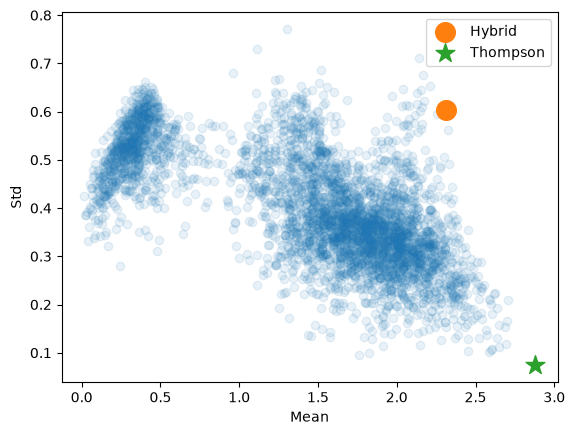


================ FINAL ENSEMBLE SUGGESTION =================

Best next input suggestion: [0.146297 0.110969 0.921484 0.215783 0.372644 0.71538 ]
Ensemble predicted mean at best input: 2.31553
Ensemble predicted std at best input: 0.60341
Final combined acquisition score at best input: 0.901587

================ TOP CANDIDATE SUGGESTIONS =================

Number of samples: 42
Input dimensions: 6
Samples per dimension: 7.0
Number of candidates: 3898
Kernel mode: ARD length scale

RationalQuadratic + UCB
----------------------------------------
Suggested next input:
[0.170456 0.18316  0.53554  0.29238  0.296611 0.744744]
Predicted mean:
2.671533
Prediction uncertainty:
0.233262
Acquisition score:
3.138056
Learned kernel:
1.25**2 * RationalQuadratic(alpha=0.1, length_scale=0.504)

RationalQuadratic + EI
----------------------------------------
Suggested next input:
[0.190312 0.203825 0.624908 0.208868 0.342778 0.722853]
Predicted mean:
2.871464
Prediction uncertainty:
0.089952
Acquisit

In [201]:
# Calculate the final EI and UCB scores for each candidate using the ensemble mean and std 
# predictions, the best observed value, and the adaptive exploration parameter xi.
ei_final = expected_improvement(
    ensemble_mean,
    ensemble_std,
    best_y,
    xi=xi
)

# Calculate the final UCB score for each candidate using the ensemble mean and std 
# predictions and the adaptive exploration weight beta.
ucb_final = ucb(
    ensemble_mean,
    ensemble_std,
    beta=2.0
)

# Calculate the final PI score for each candidate using the ensemble mean and std predictions,
# the best observed value, and the adaptive exploration parameter xi.
pi_final = probability_improvement(
    ensemble_mean,
    ensemble_std,
    best_y,
    xi=xi
)

# Normalize the final EI, UCB, and PI scores to a [0, 1] range to allow for fair combination
# of the three acquisition functions according to the adaptive weights.
#ei_norm = normalize_score_safe(ei_final, min_range=1e-9, relative_tol=1e-3)
#ucb_norm = normalize_score_safe(ucb_final, min_range=1e-9, relative_tol=1e-3)
#pi_norm = normalize_score_safe(pi_final, min_range=1e-9, relative_tol=1e-3)
# --------------------------------------------------
# Normalize acquisition scores safely
# --------------------------------------------------
#
# EI and PI can become numerically tiny once the optimiser has
# found a strong observation. Do not expand negligible values
# to the full [0, 1] range because that can make an unpromising,
# high-uncertainty candidate appear artificially strong.

ei_active = np.max(ei_final) >= 1e-6
pi_active = np.max(pi_final) >= 1e-3

if ei_active:
    ei_norm = normalize_score_safe(
        ei_final,
        min_range=1e-7,
        relative_tol=1e-2
    )
else:
    ei_norm = np.zeros_like(ei_final)

if pi_active:
    pi_norm = normalize_score_safe(
        pi_final,
        min_range=1e-4,
        relative_tol=1e-2
    )
else:
    pi_norm = np.zeros_like(pi_final)

ucb_norm = normalize_score_safe(
    ucb_final,
    min_range=1e-9,
    relative_tol=1e-3
)

print("Maximum EI:", np.max(ei_final))
print("EI active in hybrid score:", ei_active)
print("Maximum PI:", np.max(pi_final))
print("PI active in hybrid score:", pi_active)

# Combine the normalized EI, UCB, and PI scores for each candidate using the adaptive 
# optimization and exploration weights to calculate a final score that balances all three
# acquisition functions according to the current stage of optimization.
# Give PI a real contribution. The previous formula made PI weight equal to zero
# because exploitation + exploration_weight always equals 1.

base_pi_weight = 0.15

ei_weight = exploitation_weight if ei_active else 0.0
ucb_weight = exploration_weight
pi_weight = base_pi_weight if pi_active else 0.0

# Renormalize the active weights so that they sum to 1.
total_weight = ei_weight + ucb_weight + pi_weight

if total_weight <= 0:
    raise RuntimeError(
        "No active acquisition functions are available."
    )

ei_weight /= total_weight
ucb_weight /= total_weight
pi_weight /= total_weight

final_score = (
    ei_weight * ei_norm
    + ucb_weight * ucb_norm
    + pi_weight * pi_norm
)

# --------------------------------------------------
# Predicted-mean eligibility gate
# --------------------------------------------------
#
# Prevent a very low-mean candidate from winning purely because
# it has high uncertainty. Candidates must retain at least 50%
# of the best predicted mean in the current candidate pool.

best_predicted_mean = float(np.max(ensemble_mean))
mean_fraction_threshold = 0.50

mean_threshold = (mean_fraction_threshold * best_predicted_mean)

mean_eligible = ensemble_mean >= mean_threshold

# Defensive fallback in case unusual negative predictions make
# the relative threshold unsuitable.
if not np.any(mean_eligible):
    mean_eligible = np.ones_like(
        ensemble_mean,
        dtype=bool
    )

print("Best candidate-pool predicted mean:", best_predicted_mean)
print("Minimum eligible predicted mean:", mean_threshold)
print("Candidates passing mean gate:", np.sum(mean_eligible), "/", len(mean_eligible))

# --------------------------------------------------
# Thompson Sampling acquisition score
# --------------------------------------------------

thompson_samples = []

from tkinter import NONE
from joblib import Parallel, delayed

# Function to efficiently sample from a single GP model for Thompson sampling.
def fast_sample_one_gp(kernel_name, gp, candidates, seed):
    rng = np.random.default_rng(seed)
    # Use the provided seed to initialize a random number generator for reproducibility.
    mean, std = gp.predict(candidates, return_std=True)
    # Draw a sample from the predictive distribution of the GP model.
    sample = rng.normal(loc=mean, scale=std)
    # Return the kernel name and the sampled values for later aggregation.
    return kernel_name, sample

# Generate a set of random seeds for each GP model to ensure reproducible Thompson sampling.
seeds = np.random.randint(0, 1_000_000, size=len(trained_models))

# ==========================================================
# Thompson sampling
# Disabled in the final week because the final decision is
# pure posterior-mean exploitation.
# ==========================================================

if FINAL_WEEK:
    thompson_results = None
    thompson_final_score = None
else:
    # Perform Thompson sampling for each GP model in parallel.
    thompson_results = Parallel(n_jobs=-1, prefer="threads")(
        delayed(fast_sample_one_gp)(
            kernel_name,
            gp,
            candidates,
            int(seed)
        )
        for (kernel_name, gp), seed
        in zip(trained_models.items(), seeds)
    )
    # Extract the samples from the Thompson sampling results for aggregation.
    thompson_samples = [sample for kernel_name, sample in thompson_results]
    # Compute the final Thompson sampling score by averaging the samples across all GP models.
    thompson_final_score = np.mean(thompson_samples, axis=0)


# ==========================================================
# Primary candidate selection
# ==========================================================

# Identify the indices of eligible candidates based on the mean_eligible mask.
eligible_indices = np.flatnonzero(mean_eligible)
# Select the best candidate based on the final score among the eligible candidates.
best_idx = eligible_indices[np.argmax(final_score[eligible_indices])]

if FINAL_WEEK:
    # Final round:
    # no future query remains in which exploratory information
    # can be exploited, so maximise posterior expected value.
    best_idx = eligible_indices[np.argmax(ensemble_mean[eligible_indices])]


# ==========================================================
# Thompson candidate only exists before the final week
# ==========================================================

if thompson_final_score is None:
    best_idx_thompson = None
    best_input_thompson = None
else:
    # Select the best candidate based on the Thompson sampling final score.
    best_idx_thompson = int(np.argmax(thompson_final_score))
    # Retrieve the corresponding candidate input based on the identified index.
    best_input_thompson = candidates[best_idx_thompson]

# Select the best next input from the candidates using the identified index of the highest final score.
best_input = candidates[best_idx]

print("\nHybrid candidate:")
print(best_input)

# Check the distance of the selected candidate to the nearest evaluated input to ensure that it satisfies 
# the minimum-distance rule, which prevents selecting candidates that are too close to previously 
# evaluated inputs and helps maintain diversity in the exploration of the input space.  
best_distance, best_nearest_index = observed_tree.query(best_input.reshape(1, -1), k=1)
# Convert the distance and index to scalar values for easier handling.
best_distance = float(best_distance[0])
best_nearest_index = int(best_nearest_index[0])

print("Selected candidate:", np.round(best_input, 6))
print("Distance to nearest evaluated input:", round(best_distance, 8))
print("Nearest evaluated input:", np.round(X[best_nearest_index], 6))
# Check if the selected candidate violates the minimum-distance rule.
if best_distance <= candidate_min_distance:
    raise RuntimeError(
        "The selected candidate violates the minimum-distance rule."
    )
# Check if the Thompson candidate exists and print its details.
if best_input_thompson is not None:
    print("\nThompson candidate:")
    print(best_input_thompson)
    distance = np.linalg.norm(best_input - best_input_thompson)

    print("Distance:", distance)
    print("Thompson mean:", ensemble_mean[best_idx_thompson])
    print("Thompson std:", ensemble_std[best_idx_thompson])
else:
    # Thompson candidate does not exist for the final week.
    print("\nThompson sampling disabled for final week.")

plt.scatter(ensemble_mean, ensemble_std, alpha=0.1)
plt.scatter(ensemble_mean[best_idx], ensemble_std[best_idx], s=200, marker="o", label="Hybrid")
# Plot the Thompson candidate if it exists.
if best_idx_thompson is not None:
    plt.scatter(
        ensemble_mean[best_idx_thompson],
        ensemble_std[best_idx_thompson],
        s=200,
        marker="*",
        label="Thompson"
)

plt.legend()
plt.xlabel("Mean")
plt.ylabel("Std")
plt.show()

    

print("\n================ "
        "FINAL ENSEMBLE SUGGESTION "
        "=================\n"
)
print(f"Best next input suggestion: {best_input.round(6)}")
print(f"Ensemble predicted mean at best input: {ensemble_mean[best_idx]:.6g}")
print(f"Ensemble predicted std at best input: {ensemble_std[best_idx]:.6g}")
print(f"Final combined acquisition score at best input: {final_score[best_idx]:.6g}")

print("\n================ "
        "TOP CANDIDATE SUGGESTIONS "
        "=================\n"
)
print("Number of samples:", n_samples)
print("Input dimensions:", n_dimensions)
print("Samples per dimension:", round(samples_per_dimension, 4))
print("Number of candidates:", num_candidates)
print("Kernel mode:", kernel_mode)
print()
for method, result in results.items():
    print(method)
    print("-" * 40)
    print("Suggested next input:")
    print(result["input"].round(6))
    print("Predicted mean:")
    print(round(result["mean"], 6))
    print("Prediction uncertainty:")
    print(round(result["std"], 6))
    print("Acquisition score:")
    print(round(result["score"], 6))
    print("Learned kernel:")
    print(result["kernel"])
    print()

print(
    "\n================ "
    "FINAL DECISION "
    "=================\n"
)
print("Exploitation weight:", round(exploitation_weight, 4))
print("Exploration weight:", round(exploration_weight, 4))
print("EI final weight:", round(ei_weight, 4))
print("UCB final weight:", round(ucb_weight, 4))
print("PI final weight:", round(pi_weight, 4))
print("Best ensemble mean:", round(ensemble_mean[best_idx], 6))
print("Best ensemble std:", round(ensemble_std[best_idx], 6))
print("Best EI:", round(ei_final[best_idx], 6))
print("Best UCB:", round(ucb_final[best_idx], 6))
print("Best PI:", round(pi_final[best_idx], 6))
print("Final score:", round(final_score[best_idx], 6))

print("Best ensemble candidate:", candidates[best_idx])


Identify which original suggestion is closest to the best ensemble candidate by 
calculating the distance from each original suggestion to the best candidate and 
selecting the one with the smallest distance. This provides insight into which 
kernel and acquisition function combination produced a suggestion that is most 
similar to the final selected input based on the ensemble predictions. 

In [202]:
best_method = None
best_dist = np.inf

# Find the closest original suggestion to the best input.
for method, result in results.items():
    dist = np.linalg.norm(result["input"] - best_input)
    # Update the best method if this candidate is closer than the previous best.
    if dist < best_dist:
        best_dist = dist
        best_method = method

print(f"Closest original suggestion: "
    f"{best_method} "
    f"(distance={best_dist:.6f})")

print("\nBEST NEXT INPUT:")
print(best_input.round(6))

print("Estimated output at best input (ensemble mean):", round(ensemble_mean[best_idx], 6))
print("Estimated uncertainty at best input (ensemble std):", round(ensemble_std[best_idx], 6))
print("Estimated EI at best input:", round(ei_final[best_idx], 6))
print("Estimated UCB at best input:", round(ucb_final[best_idx], 6))
print("Estimated PI at best input:", round(pi_final[best_idx], 6))
print("Final acquisition score at best input:", round(final_score[best_idx], 6))

Closest original suggestion: RBF + UCB (distance=0.134278)

BEST NEXT INPUT:
[0.146297 0.110969 0.921484 0.215783 0.372644 0.71538 ]
Estimated output at best input (ensemble mean): 2.315533
Estimated uncertainty at best input (ensemble std): 0.60341
Estimated EI at best input: 0.062761
Estimated UCB at best input: 3.522353
Estimated PI at best input: 0.189208
Final acquisition score at best input: 0.901587


## Neural-network surrogate comparison

This section adds a small neural-network ensemble as an extra surrogate model. It does **not** replace the GP ensemble. The NN is trained on the same observed samples, then backpropagation is used with respect to the input vector to climb the learned surrogate surface inside the `[0, 1]` search bounds.

Use the result as a comparison candidate, especially for the higher-dimensional functions.

In [203]:
# --------------------------------------------------
# Neural-network surrogate candidate
# --------------------------------------------------
# This is an extra candidate source for comparison against the GP/hybrid result.
# It is deliberately small to reduce overfitting on the small capstone datasets.

use_nn_surrogate = True # Set to False to disable the neural-network surrogate candidate

if use_nn_surrogate:
    nn_generator = NeuralSurrogateCandidateGenerator(
        n_ensemble=5,
        hidden_units=32,
        activation="tanh",
        #activation="relu",
        learning_rate=1e-3,
        weight_decay=1e-3,
        max_epochs=1500,
        patience=200,
        gradient_steps=80,
        gradient_step_size=0.03,
        random_state=0,
        verbose=False,
    )

    # Generate the neural-network surrogate candidate.
    nn_report = nn_generator.suggest(
        X=X,
        y=y,
        candidates=candidates,
        best_gp_input=best_input,
        top_k_starts=32,
        n_random_starts=64,
    )

    print_nn_candidate_report(nn_report)

    nn_candidate = nn_report["candidate"]

    # Score the NN candidate using the already-trained GP ensemble too.
    # This gives an apples-to-apples comparison against the GP/hybrid candidate.
    nn_gp_means = []
    nn_gp_stds = []

    # Evaluate the NN candidate using each GP in the trained ensemble.
    for kernel_name, gp in trained_models.items():
        mean_one, std_one = gp.predict(nn_candidate.reshape(1, -1), return_std=True, )
        nn_gp_means.append(float(mean_one[0]))
        nn_gp_stds.append(float(std_one[0]))

    # Convert the lists of means and stds to numpy arrays for easier manipulation.
    nn_gp_means = np.asarray(nn_gp_means)
    nn_gp_stds = np.asarray(nn_gp_stds)
    # Compute the ensemble mean and standard deviation for the GP predictions at the NN candidate.
    nn_gp_ensemble_mean = float(np.mean(nn_gp_means))
    nn_gp_ensemble_std = float(np.sqrt(np.mean(nn_gp_stds ** 2) + np.var(nn_gp_means)))

    print("GP ensemble score at NN candidate")
    print("Mean:", round(nn_gp_ensemble_mean, 6))
    print("Std:", round(nn_gp_ensemble_std, 6))
    print("Distance from GP/hybrid best_input:", round(np.linalg.norm(nn_candidate - best_input), 6))

    print("\nComparison")
    print("GP/hybrid candidate:", np.round(best_input, 6))
    print("NN-gradient candidate:", np.round(nn_candidate, 6))
else:
    nn_report = None
    nn_candidate = None



================ NEURAL SURROGATE CANDIDATE ================
NN candidate:
[0.500156 0.       0.285424 0.354856 0.161842 1.      ]
NN predicted mean: 3.609067
NN ensemble std: 0.075166
NN training RMSE: 0.016273
Distance to best observed: 0.602438
Distance to GP/hybrid candidate: 0.828789
Gradient-ascent starts used: 98

GP ensemble score at NN candidate
Mean: 0.872353
Std: 0.562539
Distance from GP/hybrid best_input: 0.828789

Comparison
GP/hybrid candidate: [0.146297 0.110969 0.921484 0.215783 0.372644 0.71538 ]
NN-gradient candidate: [0.500156 0.       0.285424 0.354856 0.161842 1.      ]


### Neural-network diagnostic plot

For 2D functions, this plots the NN surrogate surface directly. For higher-dimensional functions, it plots a 2D slice through the NN candidate while fixing the other dimensions at the NN candidate value.

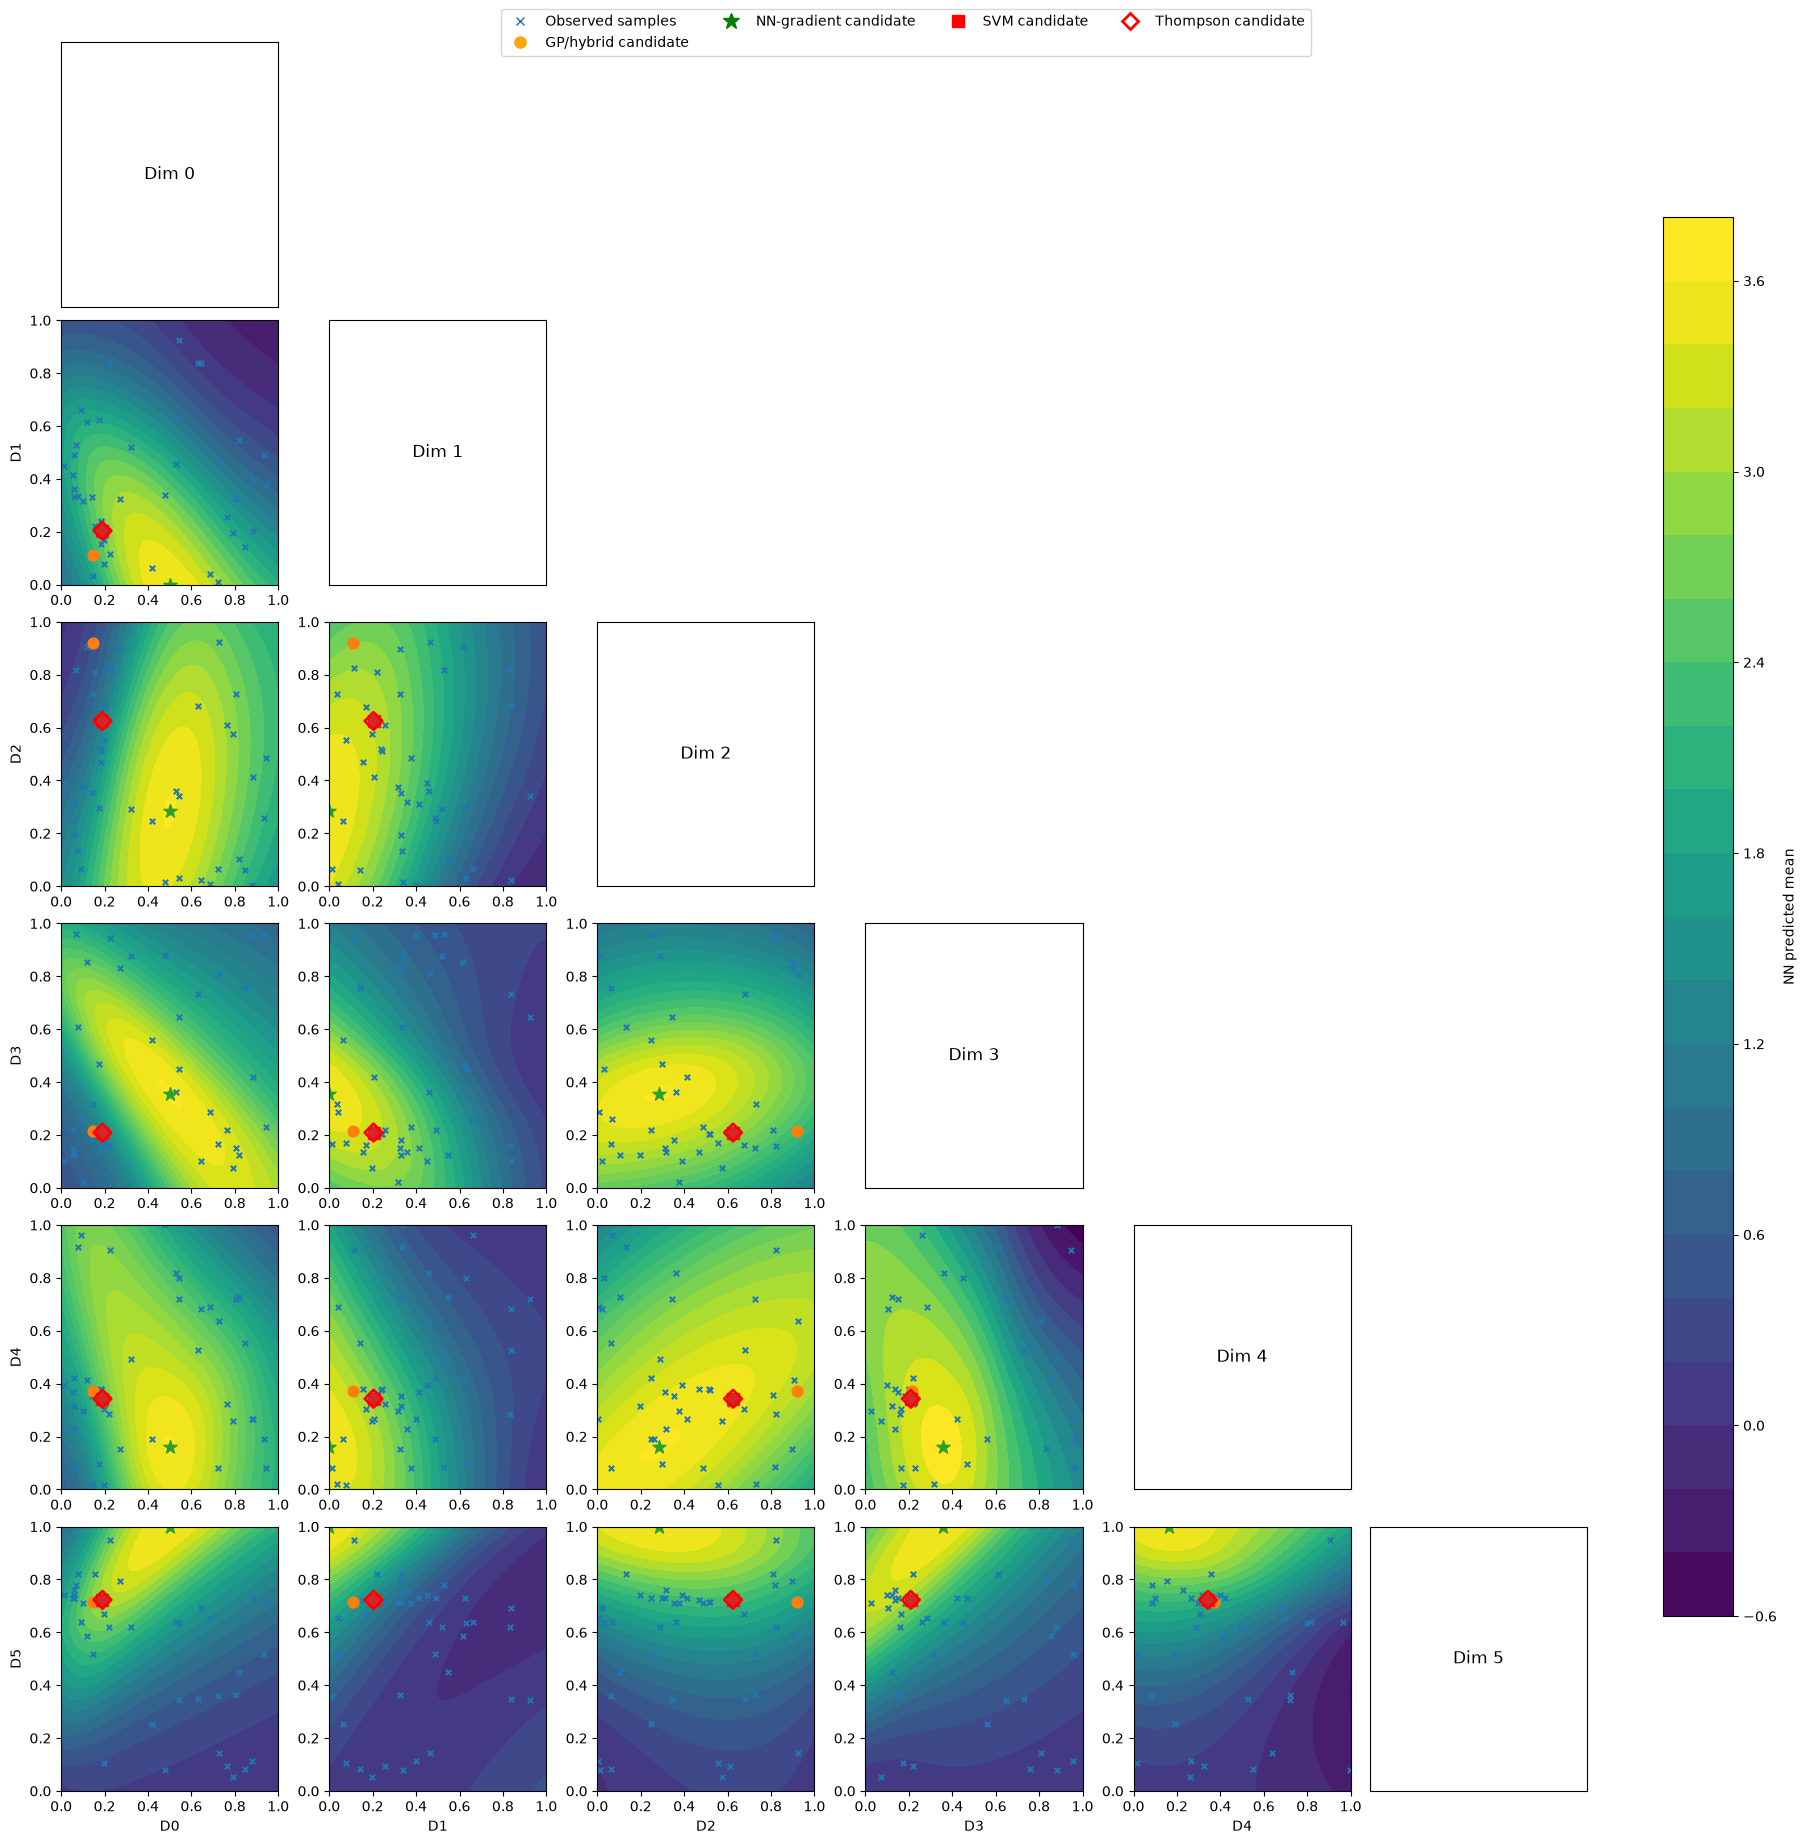

In [204]:
# Optional NN diagnostic surface/slice plot
if use_nn_surrogate and nn_report is not None:
    from matplotlib.lines import Line2D

    grid_size = 80

    # Create figure first
    fig, axes = plt.subplots(
        n_dimensions,
        n_dimensions,
        figsize=(3 * n_dimensions, 3 * n_dimensions),
        constrained_layout=True,
        squeeze=False,
    )

    # Store grids so we don't predict twice
    plot_data = {}
    global_min = np.inf
    global_max = -np.inf

    # Pass 1: compute all NN mean grids and global colour limits
    for dim_i in range(n_dimensions):
        for dim_j in range(dim_i):  # lower triangle only
            # Generate a grid of points for the current pair of dimensions.
            xi_grid = np.linspace(0.0, 1.0, grid_size)
            xj_grid = np.linspace(0.0, 1.0, grid_size)
            xx, yy_grid = np.meshgrid(xi_grid, xj_grid)
            # Create the meshgrid for plotting.
            X_plot = np.tile(nn_candidate, (grid_size * grid_size, 1))
            X_plot[:, dim_j] = xx.ravel()
            X_plot[:, dim_i] = yy_grid.ravel()
            # Predict the NN mean and standard deviation on the grid.
            nn_mean_grid, _ = nn_generator.predict(X_plot, return_std=True)
            nn_mean_grid = nn_mean_grid.reshape(grid_size, grid_size)
            # Store the grid and predicted mean for later plotting.
            plot_data[(dim_i, dim_j)] = (xx, yy_grid, nn_mean_grid)
            # Update the global minimum and maximum for the colour scale.
            global_min = min(global_min, nn_mean_grid.min())
            global_max = max(global_max, nn_mean_grid.max())

    # Pass 2: plot
    contour = None

    for dim_i in range(n_dimensions):
        for dim_j in range(n_dimensions):

            ax = axes[dim_i, dim_j]

            if dim_i == dim_j:
                ax.text(
                    0.5,
                    0.5,
                    f"Dim {dim_i}",
                    ha="center",
                    va="center",
                    fontsize=12,
                )
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            if dim_j > dim_i:
                ax.axis("off")
                continue

            xx, yy_grid, nn_mean_grid = plot_data[(dim_i, dim_j)]

            contour = ax.contourf(
                xx,
                yy_grid,
                nn_mean_grid,
                levels=20,
                vmin=global_min,
                vmax=global_max,
            )

            ax.scatter(X[:, dim_j], X[:, dim_i], marker="x", s=15)
            ax.scatter(best_input[dim_j], best_input[dim_i], marker="o", s=60)
            ax.scatter(nn_candidate[dim_j], nn_candidate[dim_i], marker="*", s=100)
            
            # only do this for SVM if it was actually used, otherwise the variable will not exist
            if svm_enabled:
                ax.scatter(best_SVM_candidate_input[dim_j], best_SVM_candidate_input[dim_i], marker="s", s=80)

            if best_input_thompson is not None:
                ax.scatter(
                    best_input_thompson[dim_j],
                    best_input_thompson[dim_i],
                    marker="D",
                    s=80,
                    facecolors="none",
                    edgecolors="red",
                    linewidths=2,
                    zorder=10,
                )

            if dim_i == n_dimensions - 1:
                ax.set_xlabel(f"D{dim_j}")

            if dim_j == 0:
                ax.set_ylabel(f"D{dim_i}")

    # Shared colourbar
    fig.colorbar(
        contour,
        ax=axes,
        shrink=0.8,
        label="NN predicted mean",
    )

    # Figure-level legend
    legend_handles = [
        Line2D([], [], marker="x", linestyle="None", label="Observed samples"),
        Line2D([], [], marker="o", linestyle="None", markersize=8, markerfacecolor="orange", markeredgecolor="orange", label="GP/hybrid candidate"),
        Line2D([], [], marker="*", linestyle="None", markersize=12, markerfacecolor="green", markeredgecolor="green", label="NN-gradient candidate"),
    ]

    if svm_enabled:
        legend_handles.append(
            Line2D([], [], marker="s", linestyle="None", markersize=8, markerfacecolor="red", markeredgecolor="red", label="SVM candidate")
        )

    if best_input_thompson is not None:
        legend_handles.append(
            Line2D([], [], marker="D", linestyle="None", markersize=8, markerfacecolor="none", markeredgecolor="red", markeredgewidth=2, label="Thompson candidate")
        )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
    )

    plt.show()


# Generate a final report for this run.

## Output of this cell is an optimisation report attempting to interpret the results of GP, SVM and NN.

In [205]:
print_automatic_optimisation_report(
    X=X,
    y=y,
    trained_models=trained_models,
    results=results,
    best_input=best_input,
    ensemble_mean=ensemble_mean,
    ensemble_std=ensemble_std,
    best_idx=best_idx,
    final_score=final_score,
    ei_final=ei_final,
    ucb_final=ucb_final,
    pi_final=pi_final,
    load_dataset=load_dataset,
    week_dataset=week_dataset,
    progress=progress,
    exploration_weight=exploration_weight,
    exploitation_weight=exploitation_weight,
    xi=xi,
    svm_enabled=svm_enabled,
    candidates=candidates,
    num_candidates_before_svm=num_candidates_before_svm,
    svm_model=svm_model,
    num_candidates=len(candidates),
    best_input_thompson=best_input_thompson,
    nn_candidate=nn_candidate,
    nn_gp_ensemble_mean=nn_gp_ensemble_mean,
    nn_gp_ensemble_std=nn_gp_ensemble_std,
    svm_candidate=best_SVM_candidate_input,
    svm_gp_mean=ensemble_mean[best_SVM_candidate_index],
    svm_gp_std=ensemble_std[best_SVM_candidate_index],
    svm_gp_ei=ei_final[best_SVM_candidate_index],
)

OPTIMISATION REPORT
1. DATASET SUMMARY
Function / dataset: 7
Week dataset: 13
Samples used: 42
Input dimensions: 6
Samples per dimension: 7.0000
Observed y min: 0.002701
Observed y max: 2.845336
Observed y mean: 0.719389
Best observed input: [0.184378 0.236845 0.520662 0.201635 0.376267 0.713072]
Best observed output: 2.845336

2. SEARCH STRATEGY
Progress through budget: 0.9231
Exploration weight / UCB: 0.3923
Exploitation weight / EI: 0.6077
EI / PI xi: 0.00169231
Generated candidates before filtering: 734846
Candidates used after filtering: 3898
SVM filtering enabled: True

3. SVM CANDIDATE COMPARISON
SVM filtering enabled: True
Candidates before SVM filtering: 734846
Candidates after SVM filtering: 3898
Candidates rejected by SVM: 730948
SVM retention rate: 0.53%

Candidate SVM support
Candidate         Accepted  SVM Score   SVM Margin   SVM Rank
--------------------------------------------------------------
GP Hybrid        Yes       0.289997     0.289997     1194
Thompson         

## Table comparisson to inspect candidates based on models.


In [206]:

# build_candidate_comparison_table currently expects a Thompson
# candidate. In the final week use the GP candidate only as a
# temporary placeholder, then remove that row immediately.

comparison_thompson_input = (
    best_input
    if best_input_thompson is None
    else best_input_thompson
)

comparison_table = build_candidate_comparison_table(
    candidates=candidates,
    best_idx=best_idx,
    best_input_thompson=comparison_thompson_input,
    nn_candidate=nn_candidate,
    ensemble_mean=ensemble_mean,
    ensemble_std=ensemble_std,
    ei_final=ei_final,
    pi_final=pi_final,
    ucb_final=ucb_final,
    svm_candidate_scores=svm_candidate_scores,
    include_svm=svm_enabled,
)

# Thompson is deliberately disabled in the terminal round.
if best_input_thompson is None:
    comparison_table = (
        comparison_table[
            comparison_table["Method"] != "Thompson Sampling"
        ]
        .reset_index(drop=True)
    )

# ==========================================================
# Table 1: Candidate Summary
# ==========================================================

candidate_summary_cols = [
    "Method",
    "GP Mean",
    "GP Std",
    "Distance to GP",
    "GP Mean Loss",
    "Candidate Role",
]

candidate_summary_table = comparison_table[candidate_summary_cols].copy()

candidate_summary_table

# ==========================================================
# Table 2: Ranking Summary
# ==========================================================

ranking_summary_cols = [
    "Method",
    "GP Mean Rank",
    "Uncertainty Rank",
]

if "SVM Rank" in comparison_table.columns:
    ranking_summary_cols.append("SVM Rank")

ranking_summary_table = comparison_table[ranking_summary_cols].copy()

ranking_summary_table

# ==========================================================
# Publication-style table
# ==========================================================

publication_cols = [
    "Method",
    "Candidate Role",
    "GP Mean",
    "GP Std",
    "GP Mean Loss",
    "Distance to GP",
]

# Only include SVM score when it exists
if "SVM Score" in comparison_table.columns:
    publication_cols.append("SVM Score")

publication_table = comparison_table[publication_cols].copy()

# Rename columns for presentation
publication_table = publication_table.rename(
    columns={
        "GP Mean": "Predicted Mean",
        "GP Std": "Predictive Std. Dev.",
        "GP Mean Loss": "Predicted Mean Loss",
        "Distance to GP": "Distance from GP Candidate",
        "SVM Score": "SVM Confidence",
    }
)

publication_table

print("==================================================")
print("Candidate Comparison Table")
print("==================================================")
#display(comparison_table) #Whole table

display(candidate_summary_table)
display(ranking_summary_table)
display(publication_table)


Candidate Comparison Table


,Method,GP Mean,GP Std,Distance to GP,GP Mean Loss,Candidate Role
0,Thompson Sampling,2.8781,0.0743,0.3155,0.0000,Alternative candidate
1,SVM,2.8781,0.0743,0.3155,0.0000,Alternative candidate
2,Final GP Choice,2.3155,0.6034,0.0000,0.5626,Exploitation baseline
3,Neural Network,0.8572,0.4940,0.9003,2.0210,Alternative candidate


,Method,GP Mean Rank,Uncertainty Rank,SVM Rank
0,Thompson Sampling,1,3898,1
1,SVM,1,3898,1
2,Final GP Choice,154,132,1194
3,Neural Network,3041,933,3700


,Method,Candidate Role,Predicted Mean,Predictive Std. Dev.,Predicted Mean Loss,Distance from GP Candidate,SVM Confidence
0,Thompson Sampling,Alternative candidate,2.8781,0.0743,0.0000,0.3155,0.7871
1,SVM,Alternative candidate,2.8781,0.0743,0.0000,0.3155,0.7871
2,Final GP Choice,Exploitation baseline,2.3155,0.6034,0.5626,0.0000,0.2900
3,Neural Network,Alternative candidate,0.8572,0.4940,2.0210,0.9003,0.1141


# 10. PCA Diagnostics — ≥90% Variance Coverage

This section uses **Principal Component Analysis (PCA) as a diagnostic only**. It does not change the GP, NN, SVM, Thompson sampling, acquisition scores, or final candidate selection.

PCA is fitted to the **observed input data `X`**. The notebook then automatically retains the **minimum number of principal components needed to explain at least 90% of the observed input variance**. The observed samples, generated candidate cloud, and GP/Hybrid, Thompson, NN and SVM candidate suggestions are projected into that same retained PCA space.

The diagnostics include:

- explained and cumulative variance for every principal component;
- automatic selection of `PC1 ... PCn` where cumulative explained variance first reaches ≥90%;
- component loadings for all retained PCs;
- a **lower-triangle PCA matrix** for every retained PC combination, with component distributions on the diagonal and an explicit model-marker legend;
- top-25% and best-observed highlights on every projection;
- GP/Hybrid, Thompson, NN and SVM candidate markers on every projection;
- cross-model distances calculated in the **full retained PCA subspace**, alongside original-space distance.

> **Interpretation caution:** PCA is unsupervised. It finds directions of variation in `X`, not directions that necessarily cause high `y`. PCA therefore remains an interpretation tool rather than a dimensionality-reduction step for the optimisation model.


PCA DIAGNOSTICS - >=90% VARIANCE COVERAGE

Explained variance by principal component:


,Principal Component,Explained Variance,Cumulative Variance,Retained for target
0,PC1,0.318,0.318,True
1,PC2,0.217,0.534,True
2,PC3,0.210,0.744,True
3,PC4,0.104,0.848,True
4,PC5,0.086,0.934,True
5,PC6,0.066,1.000,False



Minimum components required for target variance: 5 (PC1-PC5), explaining 93.4%.


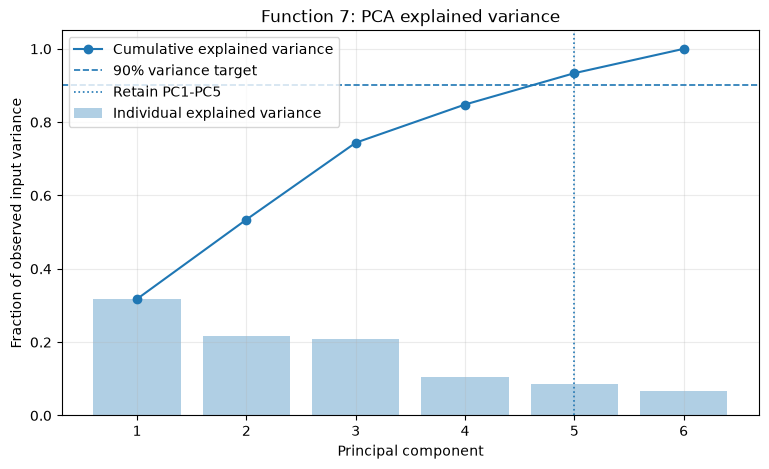


PCA loadings for retained components PC1-PC5:


,PC1 loading,PC2 loading,PC3 loading,PC4 loading,PC5 loading
x1,0.683,-0.163,-0.331,0.299,-0.061
x2,0.087,0.170,0.400,0.582,-0.650
x3,-0.293,0.594,-0.383,0.540,0.347
x4,0.407,0.765,0.141,-0.466,-0.092
x5,0.265,-0.039,0.668,0.241,0.651
x6,-0.451,0.067,0.344,-0.065,-0.143



Creating lower-triangle PCA matrix for PC1-PC5 (10 unique pairwise projections).


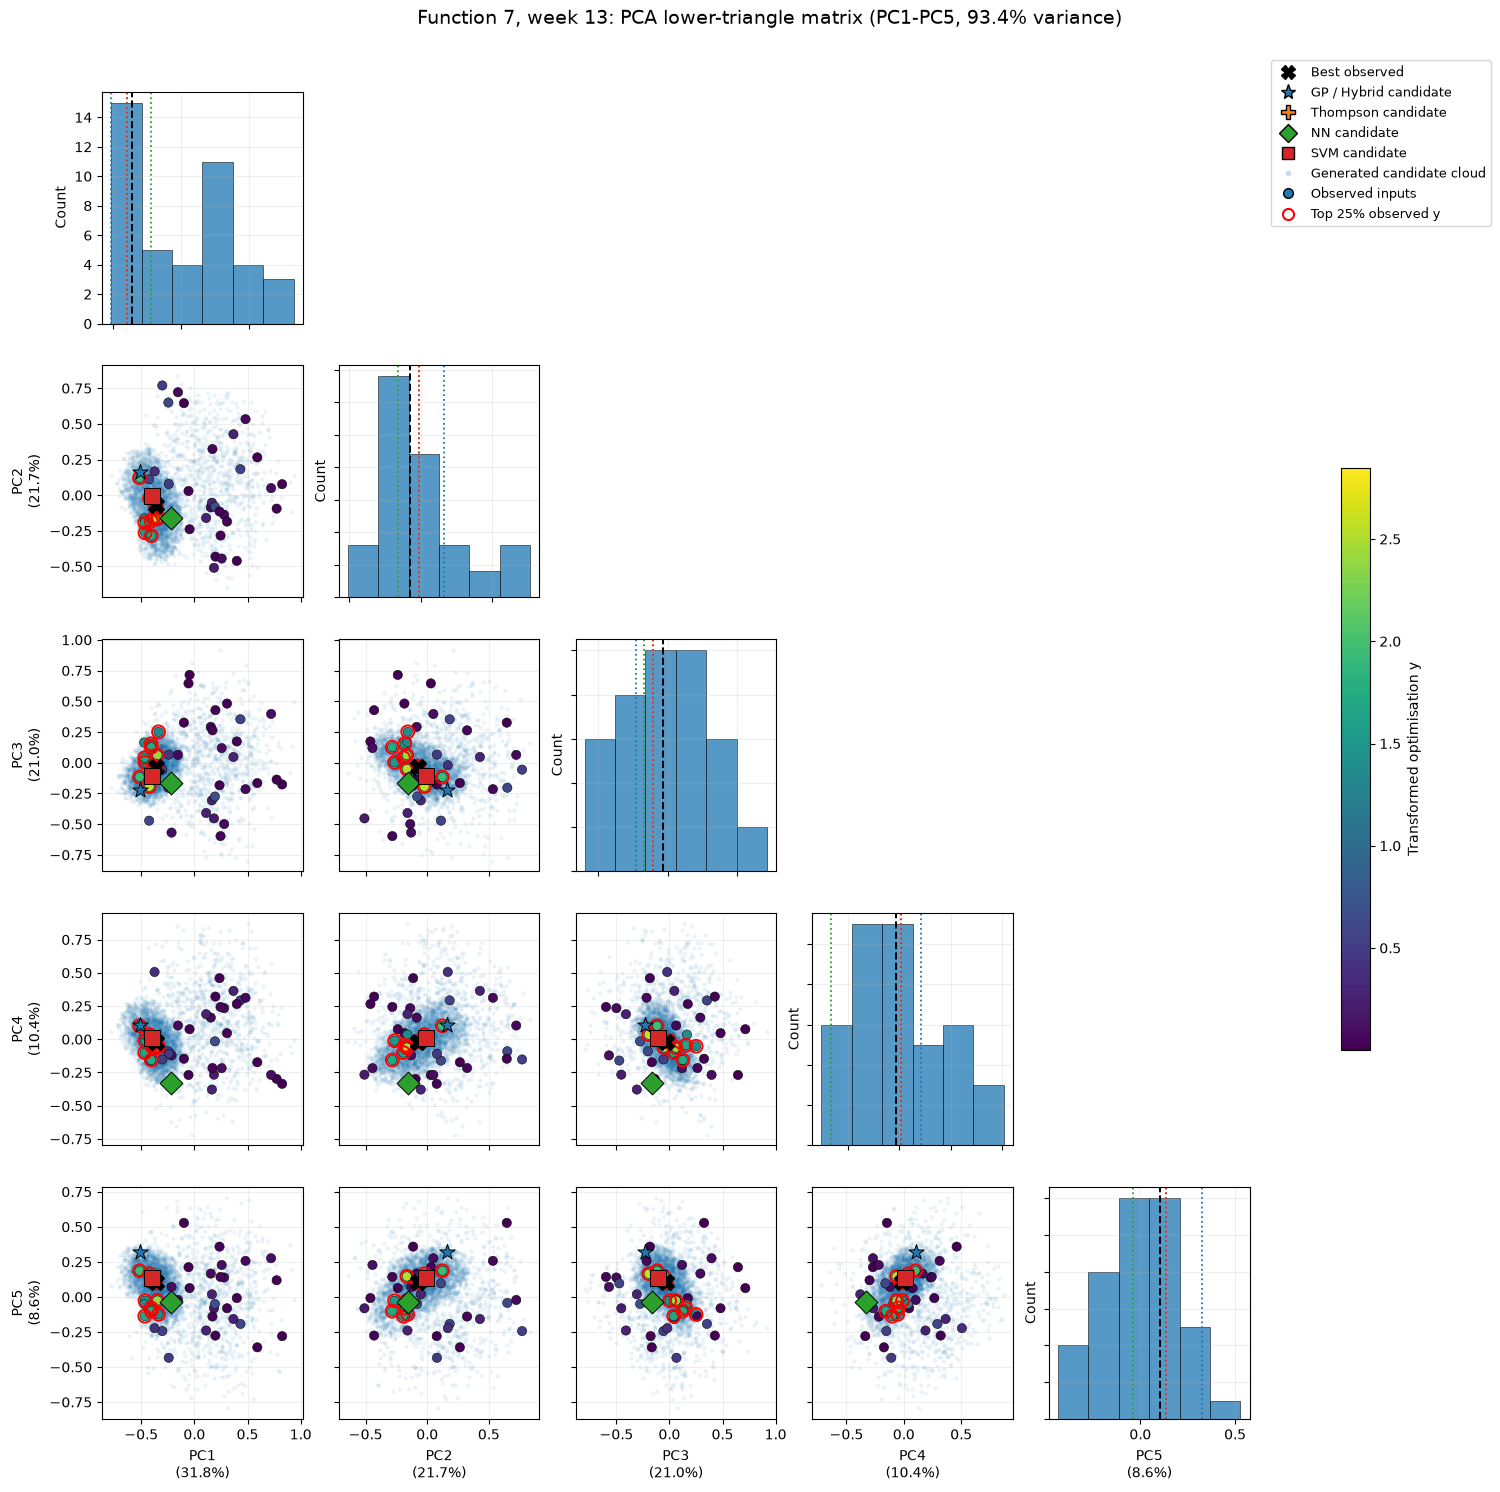


Cross-model candidate positions in retained PCA space (PC1-PC5):


,Method,PC1,PC2,PC3,PC4,PC5,PC1-PC5 distance from GP,Original-space distance from GP
0,GP / Hybrid,-0.5137,0.1620,-0.2257,0.1064,0.3230,0.0000,0.0000
1,Thompson,-0.4028,-0.0090,-0.1081,0.0090,0.1371,0.3154,0.3155
2,NN,-0.2230,-0.1583,-0.1671,-0.3302,-0.0381,0.7153,0.8288
3,SVM,-0.4028,-0.0090,-0.1081,0.0090,0.1371,0.3154,0.3155



The retained PCA distance uses all 5 components needed to explain 93.4% of observed input variance. It remains an interpretation aid; the original-space distance is still the primary geometric measure.


In [207]:

# ==========================================================
# PCA Diagnostics
# Change target_variance to adjust the number of principal components retained for analysis.
# ==========================================================

target_variance = 0.9  # Adjust this value to retain more or fewer principal components

pca_results = run_pca_diagnostics(
    X=X,
    y=y,
    candidates=candidates,
    load_dataset=load_dataset,
    week_dataset=week_dataset,
    best_input=best_input,
    best_input_thompson=best_input_thompson,
    nn_candidate=nn_candidate,
    svm_enabled=svm_enabled,
    target_variance=target_variance,
    best_SVM_candidate_input=best_SVM_candidate_input,
)


## 10.1 Extended PCA Diagnostic Reporting

This section turns the PCA projection into quantitative diagnostics for late-stage optimisation. It remains **diagnostic only** and does not alter candidate generation, surrogate fitting, acquisition scores, or final candidate selection.

The diagnostics compare each model-selected candidate with the observed high-performing region, quantify cross-model agreement, identify which retained PCs are most associated with observed output, and report how compact or dispersed the top-performing observations are. Distances in retained PCA space are interpretation aids; original-space distances remain the primary geometric reference.


EXTENDED PCA DIAGNOSTIC REPORTING

1. HIGH-PERFORMING OBSERVED REGION
Observed samples: 42
Top-25% threshold: y >= 1.360398
High-y samples: 11
Retained PCA subspace: PC1-PC5 (93.4% variance)
High-y region mean radius from its centroid:   0.2014
High-y region median radius from its centroid: 0.1738
High-y region maximum radius from its centroid:0.3775


,Principal Component,All-observation centroid,Top-25% y centroid,Best observed,High-y centroid shift
0,PC1,0.0000,-0.4066,-0.3631,-0.4066
1,PC2,-0.0000,-0.1327,-0.0719,-0.1327
2,PC3,0.0000,0.0191,-0.0351,0.0191
3,PC4,-0.0000,-0.0357,-0.0178,-0.0357
4,PC5,0.0000,0.0187,0.1036,0.0187



2. RETAINED-PC ASSOCIATION WITH OBSERVED OUTPUT
Note: PCA itself does not use y; these are post-hoc associations, not causal effects.


,PC,Explained variance,Pearson corr with y,Spearman corr with y,Top-25% mean PC score,Other-observation mean PC score,Standardized high-y shift,|Spearman| rank
0,PC1,31.8%,-0.690,-0.746,-0.4066,+0.1443,-1.427,1
2,PC3,21.0%,-0.039,-0.148,+0.0191,-0.0068,+0.083,2
1,PC2,21.7%,-0.173,-0.065,-0.1327,+0.0471,-0.564,3
3,PC4,10.4%,-0.074,+0.046,-0.0357,+0.0127,-0.219,4
4,PC5,8.6%,+0.041,-0.035,+0.0187,-0.0066,+0.126,5



3. MODEL CANDIDATE PROXIMITY TO THE HIGH-PERFORMING REGION
'High-y radius units' compares candidate distance to the top-25% centroid with the mean radius of that region.


...

,GP / Hybrid,Thompson,NN,SVM
GP / Hybrid,0.0000,0.3155,0.8288,0.3155
Thompson,0.3155,0.0000,0.6194,0.0000
NN,0.8288,0.6194,0.0000,0.6194
SVM,0.3155,0.0000,0.6194,0.0000



Model consensus summary (smaller mean distance = greater agreement with the other models):


,Method,Mean PCA distance to other models,Mean original distance to other models,PCA consensus rank
1,Thompson,0.2556,0.3116,1
3,SVM,0.2556,0.3116,1
0,GP / Hybrid,0.4487,0.4866,3
2,NN,0.5394,0.6892,4



5. PER-PC CANDIDATE DEVIATION FROM THE TOP-25% CENTROID


,Method,PC,Candidate score,High-y centroid,Difference,Difference in high-y SD units
0,GP / Hybrid,PC1,-0.5137,-0.4066,-0.1071,-1.90
1,GP / Hybrid,PC2,+0.1620,-0.1327,+0.2947,+2.55
2,GP / Hybrid,PC3,-0.2257,+0.0191,-0.2449,-1.93
3,GP / Hybrid,PC4,+0.1064,-0.0357,+0.1420,+2.10
4,GP / Hybrid,PC5,+0.3230,+0.0187,+0.3043,+2.46
5,Thompson,PC1,-0.4028,-0.4066,+0.0038,+0.07
6,Thompson,PC2,-0.0090,-0.1327,+0.1236,+1.07
7,Thompson,PC3,-0.1081,+0.0191,-0.1272,-1.01
8,Thompson,PC4,+0.0090,-0.0357,+0.0447,+0.66
9,Thompson,PC5,+0.1371,+0.0187,+0.1184,+0.96


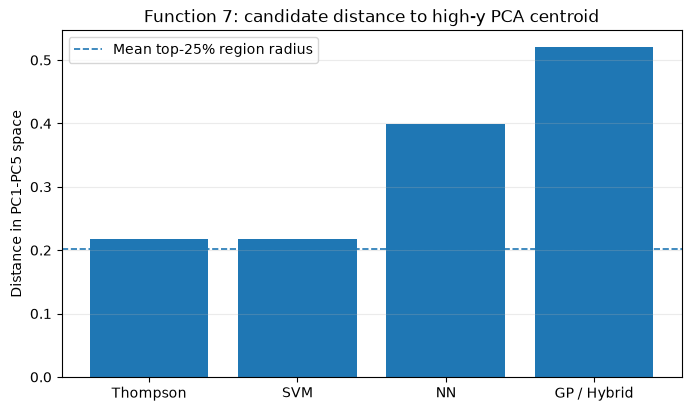

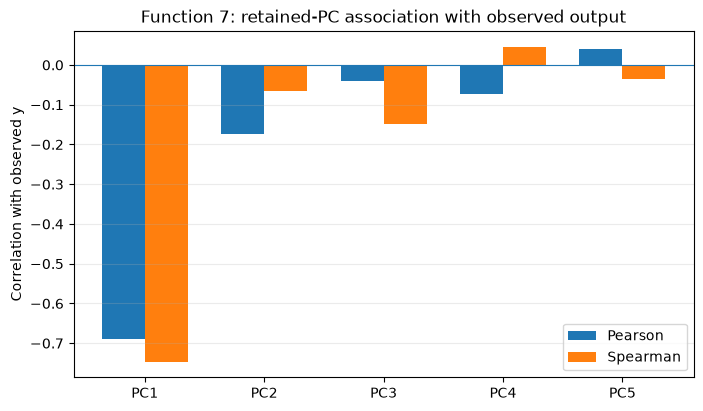


6. PCA DIAGNOSTIC INTERPRETATION SUMMARY
--------------------------------------------------
Closest model candidate to the top-25% PCA centroid: Thompson (distance 0.2179, 1.08 high-y mean-radius units).
Greatest cross-model consensus: Thompson (mean retained-PCA distance to other model candidates 0.2556).
Strongest monotonic PC-y association among retained components: PC1 (Spearman -0.746; explained variance 31.8%).
Top-25% observed points have a mean PCA radius of 0.2014; use this as a rough scale when judging whether a candidate lies inside, near, or outside the established high-performing region.
Interpretation caution: PCA is fitted only to X and is unsupervised. PC-y correlations, centroid distances, and proximity ranks describe the current observed sample; they do not prove causality or guarantee that the nearest candidate will produce the highest next y.


In [208]:
extended_pca_results = run_extended_pca_diagnostics(
    pca_results=pca_results,
    load_dataset=load_dataset,
)

# 11. GP Diagnostics

Display the existing Gaussian Process diagnostic plots.


SVM_best_idx: 1775
SVM_best_input: [0.19031244 0.2038254  0.62490771 0.20886846 0.34277834 0.72285304]
SVM_best_Output: 2.878132880909634


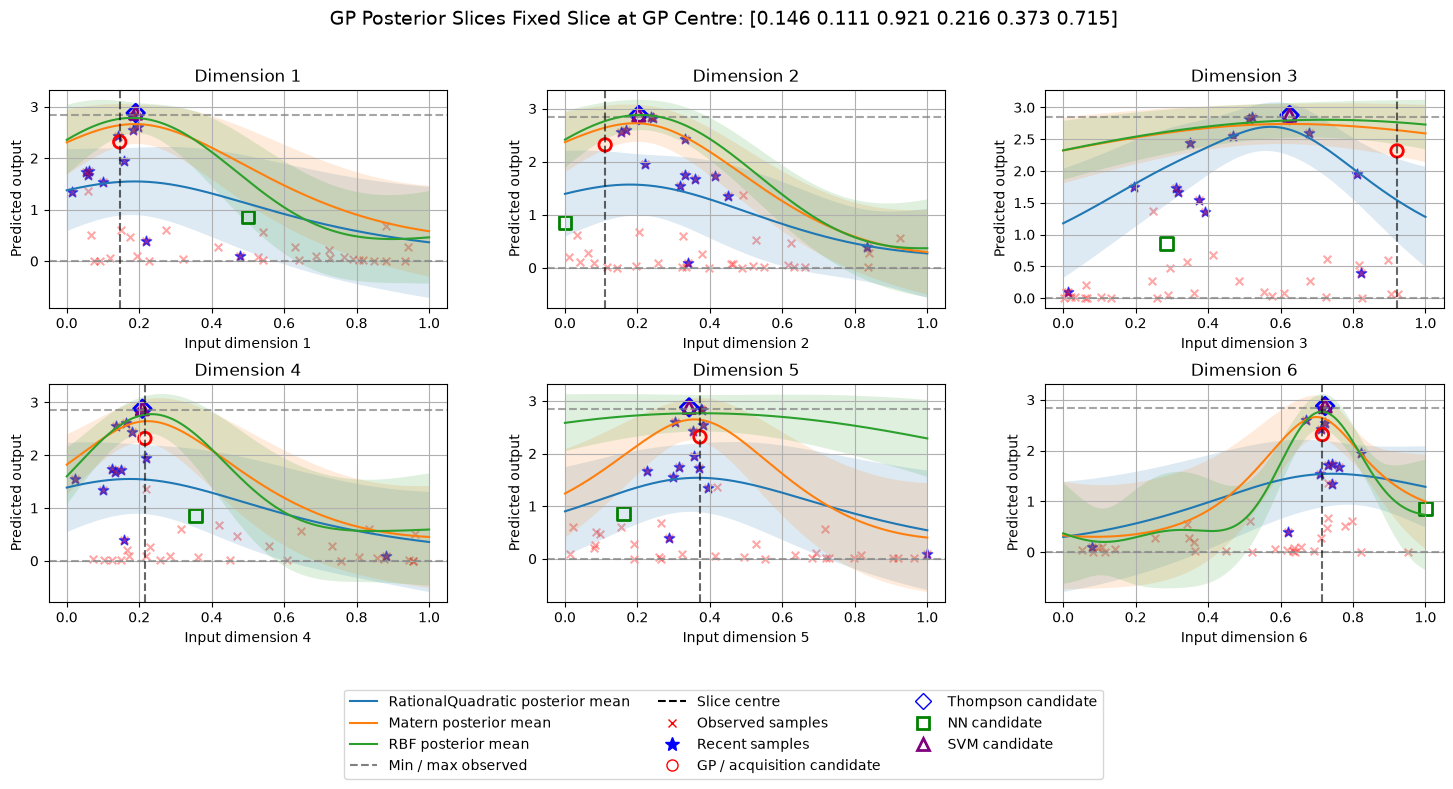

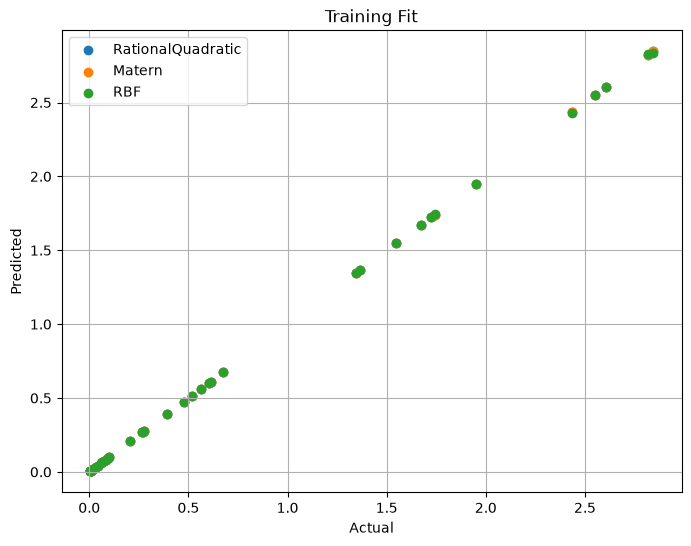

RationalQuadratic max training std: 0.0009085192643587954
Matern max training std: 0.0009085191396378123
RBF max training std: 0.00908415959586582


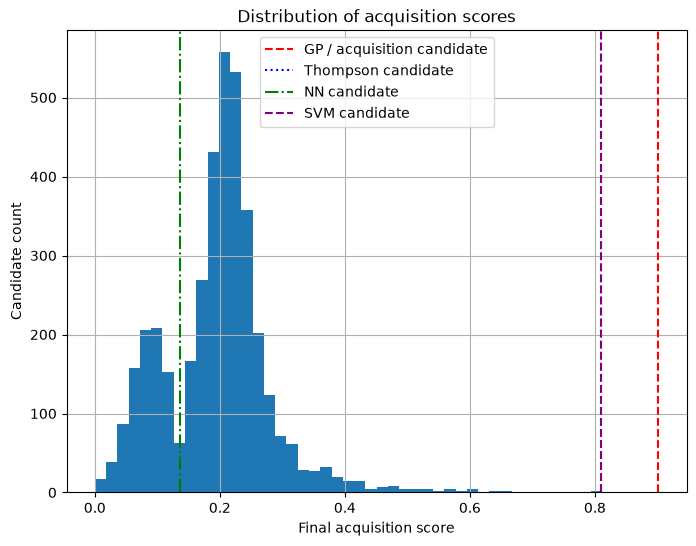

Selected candidate percentile: 100.0000%
Best score: 0.9015868068827165
Second best: 0.8825398621712041
Gap: 0.01904694471151247

Top candidates
------------------------------------------------------------
 1: score=0.901587, mean=2.316, std=0.603, x=[0.1462965  0.11096869 0.92148426 0.21578298 0.37264439 0.71537995]
 2: score=0.882540, mean=2.144, std=0.711, x=[0.10837382 0.20702742 0.98706902 0.26963961 0.28828373 0.69447387]
 3: score=0.852233, mean=2.212, std=0.654, x=[0.24971946 0.23354284 0.96637107 0.17038555 0.3193114  0.69992025]
 4: score=0.837705, mean=2.169, std=0.676, x=[0.11621768 0.26352978 0.97092649 0.23985622 0.3601059  0.67367805]
 5: score=0.809186, mean=2.878, std=0.074, x=[0.19031244 0.2038254  0.62490771 0.20886846 0.34277834 0.72285304]
 6: score=0.808032, mean=2.323, std=0.561, x=[0.1406262  0.20912526 0.90262634 0.20502324 0.28541605 0.73039079]
 7: score=0.776666, mean=2.253, std=0.595, x=[0.10797743 0.17691054 0.90153342 0.27480048 0.28247094 0.70118179]
 8:

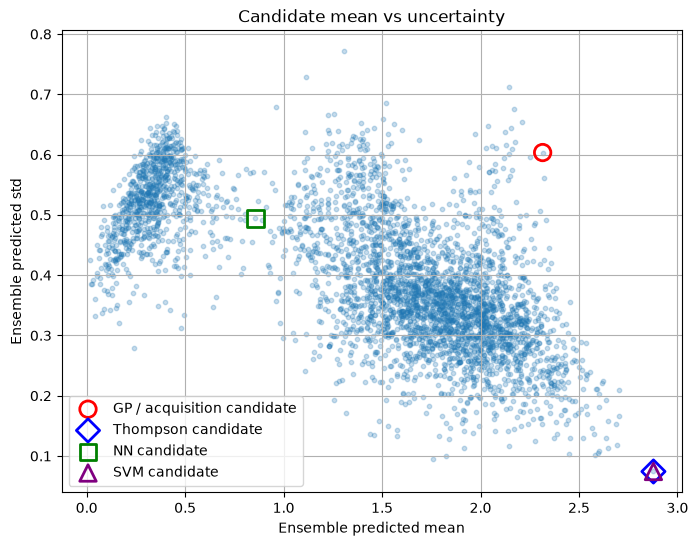

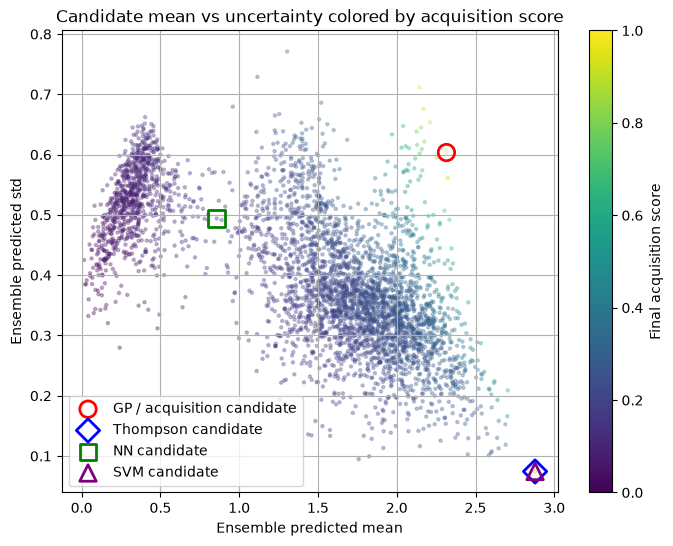

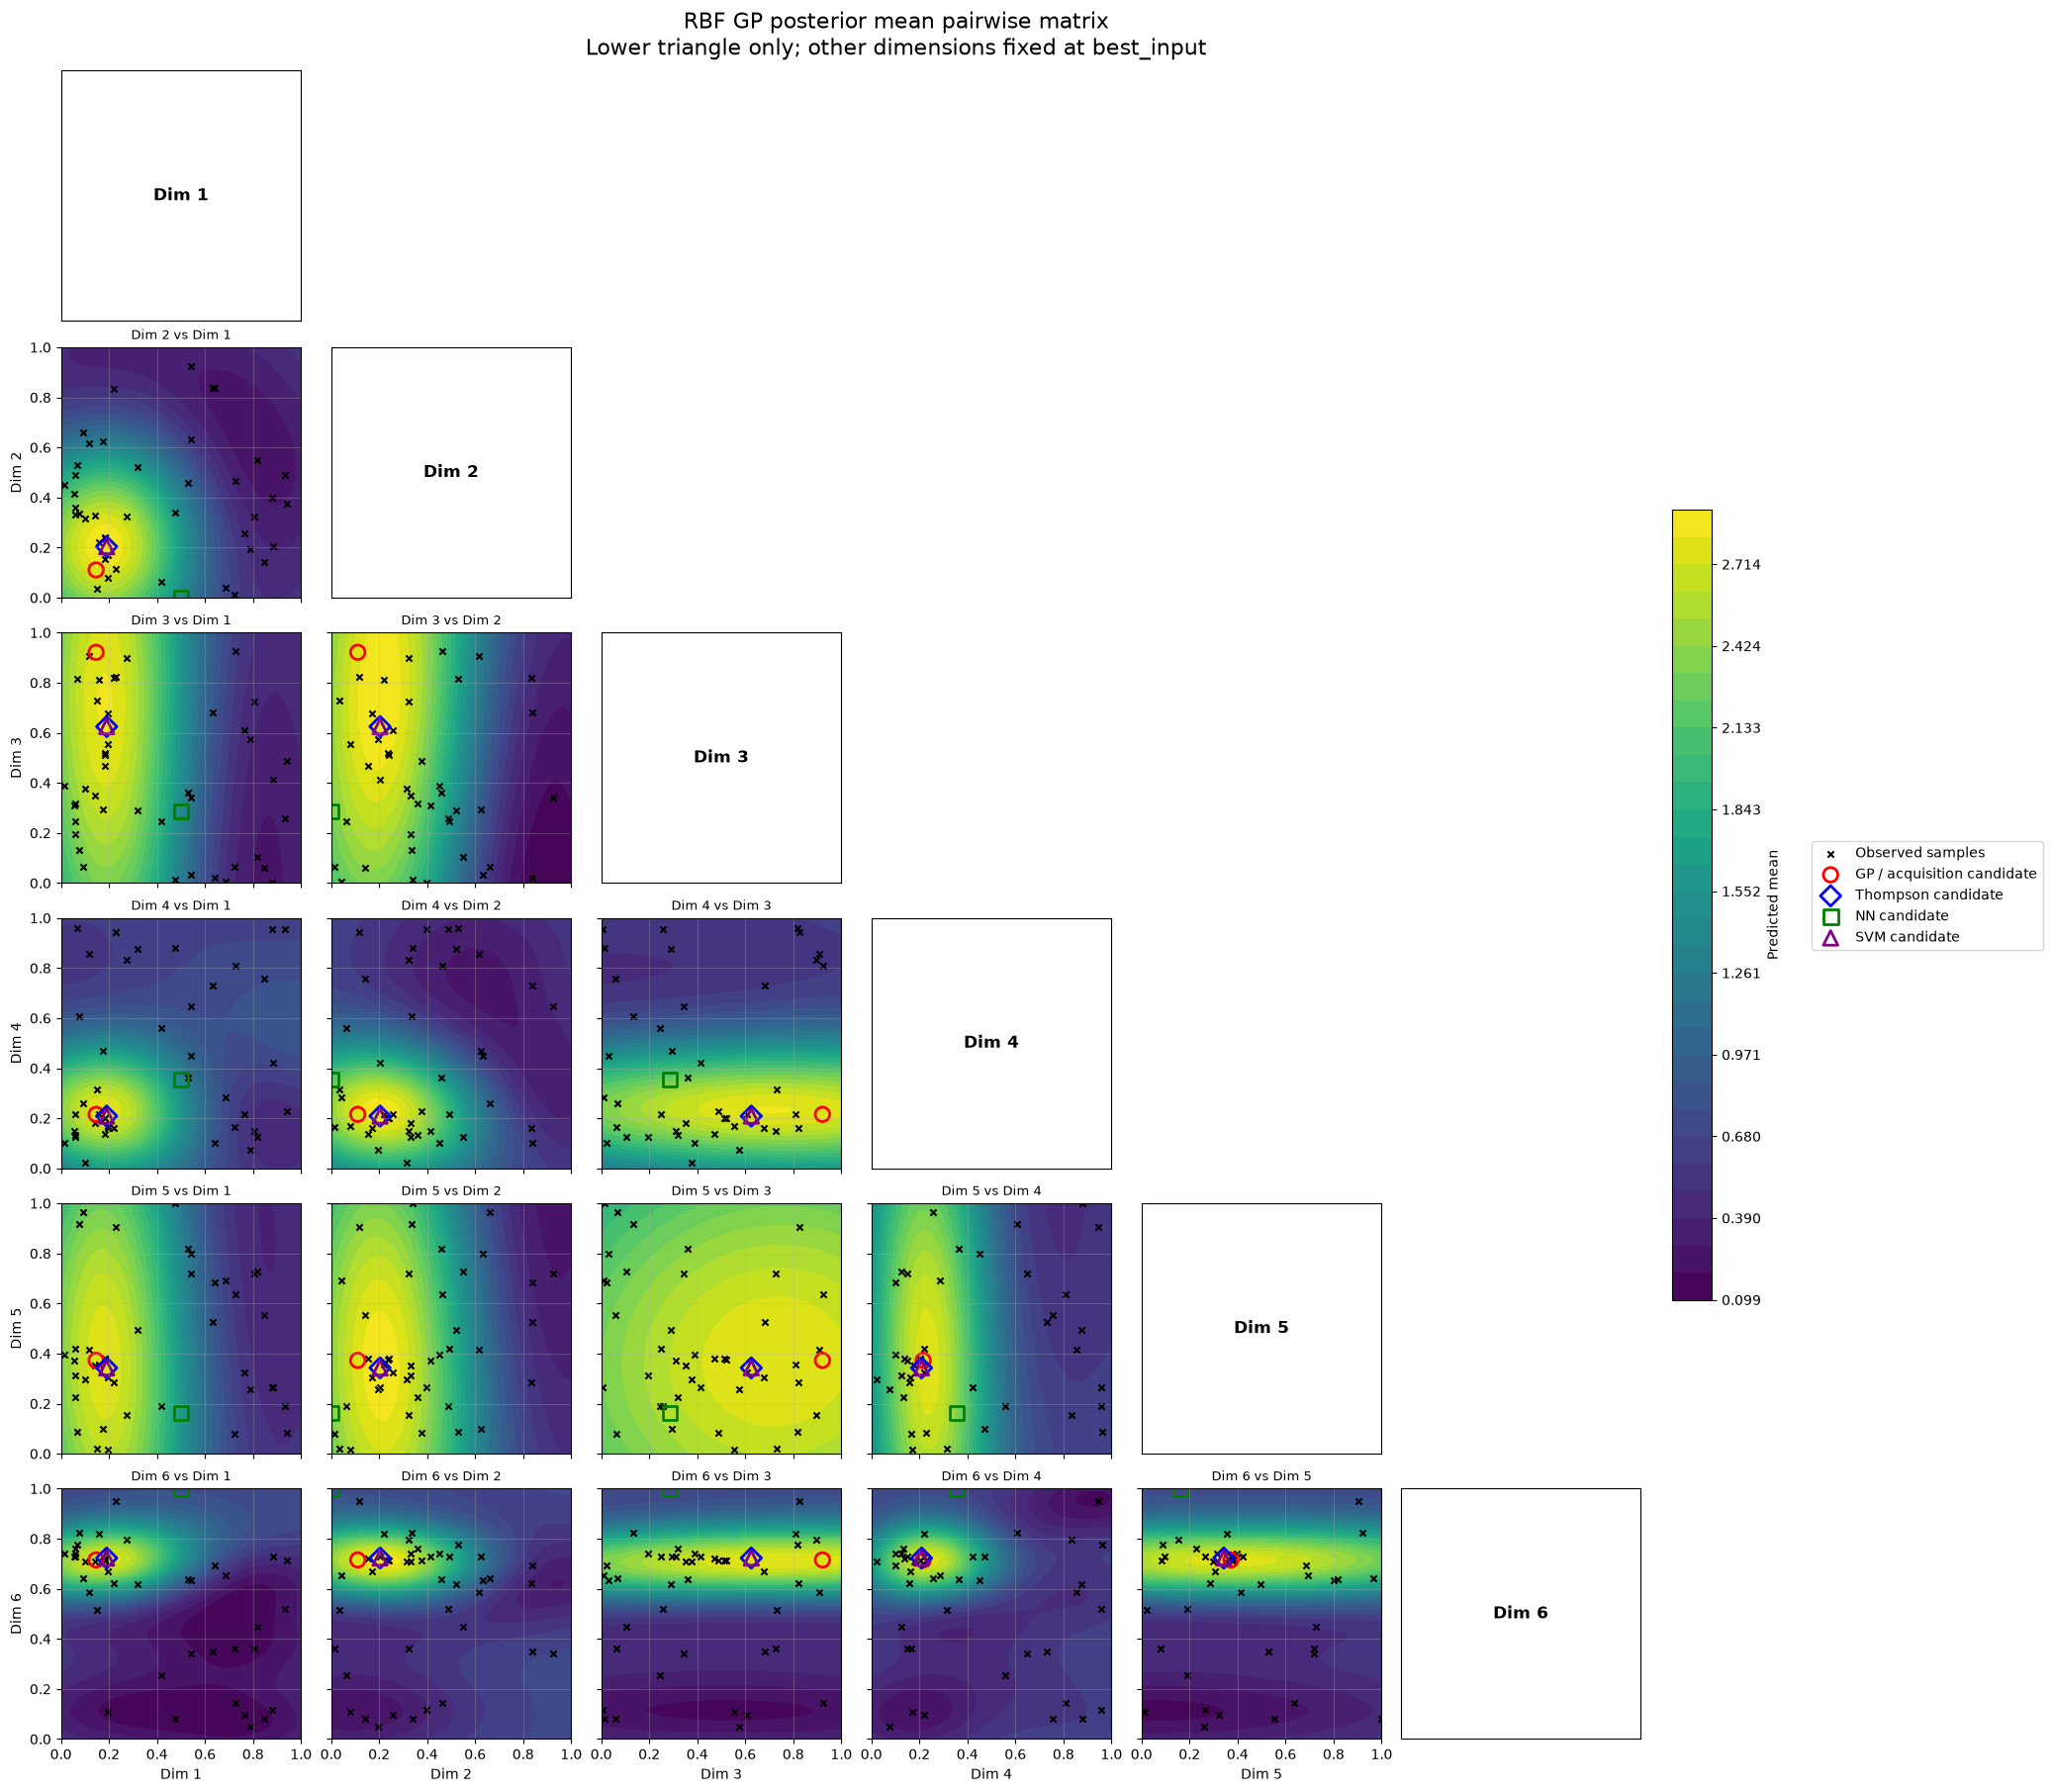


Process complete.


In [209]:
from src.gp_diagnostics import run_gp_diagnostics

print("SVM_best_idx:", best_SVM_candidate_index)
print("SVM_best_input:", best_SVM_candidate_input)

SVM_best_Output = ensemble_mean[best_SVM_candidate_index]
print("SVM_best_Output:", SVM_best_Output) 

if best_input_thompson is not None:
    run_gp_diagnostics(
        X=X,
        y=y,
        trained_models=trained_models,
        best_input=best_input,
        NN_best_input=nn_candidate,
        Thompson_best_input=best_input_thompson,
        SVM_best_input=best_SVM_candidate_input,
        ensemble_mean=ensemble_mean,
        ensemble_std=ensemble_std,
        final_score=final_score,
        best_idx=best_idx,
        thompson_best_idx=best_idx_thompson,
        SVM_best_idx=best_SVM_candidate_index,
        candidates=candidates,
        week_dataset=week_dataset,
        n_dimensions=n_dimensions,
    )
else:
    print(
        "Full GP candidate diagnostics skipped: "
        "Thompson sampling is disabled for the final week."
    )
    

# Optional export functions to JSON files for use with streamlit app.

## To output the file GENERATE_JSON_FILES must be set to True at the top of this notebook.

In [210]:
# ==========================================================
# EXPORT RUN SUMMARY FOR STREAMLIT
# Objective-aware version:
# - Keeps the original/raw black-box output for human-facing reporting
# - Keeps the transformed y value used internally by the optimiser
# - Correctly handles original minimisation objectives
# ==========================================================

import json
from pathlib import Path
from datetime import datetime
import numpy as np


from sklearn.decomposition import PCA


def to_json_safe(value):
    """
    Recursively convert NumPy, Pandas and sklearn PCA objects
    into JSON-safe Python types.
    """

    if value is None:
        return None

    # ------------------------------------------------------
    # sklearn PCA model
    # ------------------------------------------------------
    if isinstance(value, PCA):
        return {
            "n_components": int(value.n_components_)
                if hasattr(value, "n_components_")
                else value.n_components,

            "explained_variance":
                to_json_safe(value.explained_variance_)
                if hasattr(value, "explained_variance_")
                else None,

            "explained_variance_ratio":
                to_json_safe(value.explained_variance_ratio_)
                if hasattr(value, "explained_variance_ratio_")
                else None,

            "singular_values":
                to_json_safe(value.singular_values_)
                if hasattr(value, "singular_values_")
                else None,

            "components":
                to_json_safe(value.components_)
                if hasattr(value, "components_")
                else None,

            "mean":
                to_json_safe(value.mean_)
                if hasattr(value, "mean_")
                else None,

            "noise_variance":
                float(value.noise_variance_)
                if hasattr(value, "noise_variance_")
                else None,
        }

    # ------------------------------------------------------
    # NumPy arrays
    # ------------------------------------------------------
    if isinstance(value, np.ndarray):
        return [
            to_json_safe(v)
            for v in value.tolist()
        ]

    # NumPy scalar
    if isinstance(value, np.generic):
        return value.item()

    # Dictionaries
    if isinstance(value, dict):
        return {
            str(k): to_json_safe(v)
            for k, v in value.items()
        }

    # Lists / tuples / sets
    if isinstance(value, (list, tuple, set)):
        return [
            to_json_safe(v)
            for v in value
        ]

    # Pandas-style objects
    if hasattr(value, "to_dict"):
        try:
            return to_json_safe(
                value.to_dict(orient="records")
            )
        except TypeError:
            return to_json_safe(
                value.to_dict()
            )

    # ------------------------------------------------------
    # Final defensive fallback
    # ------------------------------------------------------
    try:
        json.dumps(value)
        return value
    except TypeError:
        return str(value)


# ----------------------------------------------------------
# Original objective direction and best observed point
# ----------------------------------------------------------

# Functions 3 and 6 are original minimisation problems that are
# converted to maximisation internally by negating raw_y.
if load_dataset in [3, 6]:
    objective_direction = "minimise"
    best_observed_idx = int(np.argmin(raw_y))

# Function 1 has a special transformation:
# y = log1p(abs(raw_y))
# The sign information is intentionally discarded, so the optimiser's
# transformed objective is the most meaningful definition of "best".
elif load_dataset == 1:
    objective_direction = "maximise_transformed"
    best_observed_idx = int(np.argmax(y))

# Remaining functions maximise the original/raw output directly.
else:
    objective_direction = "maximise"
    best_observed_idx = int(np.argmax(raw_y))


best_observed_input = X[best_observed_idx]

# Human-facing/original value
best_observed_raw_output = float(raw_y[best_observed_idx])

# Internal optimiser value
best_observed_transformed_output = float(y[best_observed_idx])


# ----------------------------------------------------------
# Convert GP prediction back to original/raw objective space
# where a meaningful inverse transformation exists
# ----------------------------------------------------------

gp_predicted_transformed = float(ensemble_mean[best_idx])

if load_dataset in [3, 6]:
    # y = -raw_y  ->  raw_y = -y
    gp_predicted_raw = -gp_predicted_transformed

elif load_dataset == 1:
    # y = log1p(abs(raw_y))
    # Only the magnitude can be recovered because abs() removed the sign.
    gp_predicted_raw = float(np.expm1(gp_predicted_transformed))

else:
    gp_predicted_raw = gp_predicted_transformed


# ----------------------------------------------------------
# GP model information
# ----------------------------------------------------------

gp_models = {}

for kernel_name, gp in trained_models.items():

    gp_models[kernel_name] = {
        "kernel": str(gp.kernel_),
        "log_marginal_likelihood": float(
            gp.log_marginal_likelihood(gp.kernel_.theta)
        ),
    }


# ----------------------------------------------------------
# Main run summary
# ----------------------------------------------------------

summary = {

    "run": {
        "function": int(load_dataset),
        "week": int(week_dataset),
        "timestamp": datetime.now().isoformat(),
        "dimensions": int(n_dimensions),
        "samples": int(len(X)),
    },

    "objective": {
        "direction": objective_direction,
        "output_transform": output_transform,
    },

    "best_observed": {
        "input": to_json_safe(best_observed_input),
        "raw_output": best_observed_raw_output,
        "transformed_output": best_observed_transformed_output,
        "objective_direction": objective_direction,
        "output_transform": output_transform,
    },

    "gp_hybrid_candidate": {
        "input": to_json_safe(best_input),

        # Human-facing prediction in original objective space
        "predicted_output": gp_predicted_raw,

        # Internal prediction used by acquisition functions
        "predicted_output_transformed": gp_predicted_transformed,

        "predicted_std": float(ensemble_std[best_idx]),
        "ei": float(ei_final[best_idx]),
        "ucb": float(ucb_final[best_idx]),
        "pi": float(pi_final[best_idx]),
        "final_score": float(final_score[best_idx]),
    },

    "thompson_candidate": {
        "enabled": best_input_thompson is not None,
        "input": to_json_safe(best_input_thompson),
    },

    "neural_network_candidate": {
        "input": to_json_safe(nn_candidate),
        "gp_predicted_mean": float(nn_gp_ensemble_mean),
        "gp_predicted_std": float(nn_gp_ensemble_std),
    },

    "svm_candidate": {
        "enabled": bool(svm_enabled),
        "input": to_json_safe(best_SVM_candidate_input),
        "gp_predicted_mean": float(
            ensemble_mean[best_SVM_candidate_index]
        ),
        "gp_predicted_std": float(
            ensemble_std[best_SVM_candidate_index]
        ),
    },

    "strategy": {
        "progress": float(progress),
        "exploration_weight": float(exploration_weight),
        "exploitation_weight": float(exploitation_weight),
        "xi": float(xi),
    },

    "candidate_pool": {
        "before_svm": int(num_candidates_before_svm),
        "final": int(len(candidates)),
    },

    "gp_models": gp_models,

    "candidate_comparison":
        to_json_safe(comparison_table),

    "pca":
        to_json_safe(pca_results),

    "extended_pca":
        to_json_safe(extended_pca_results),
}

# ==========================================================
# FUNCTION 4 FINAL LOCAL-GP SUBMISSION INFORMATION
# ==========================================================
#
# Preserve the global GP result above for diagnostics, but
# record the actual terminal submission candidate selected
# using the Function 4 local GP.
# ==========================================================

if FINAL_WEEK and load_dataset == 4 and local_gp is not None:

    summary["final_submission_candidate"] = {
        "method": "Function 4 local GP terminal exploitation",

        "input": to_json_safe(
            local_best_input
        ),

        "predicted_output": float(
            local_best_mean
        ),

        "predicted_output_transformed": float(
            local_best_mean
        ),

        "predicted_std": float(
            local_best_std
        ),

        "distance_from_best_observed": float(
            np.linalg.norm(
                local_best_input - incumbent
            )
        ),

        "selection_reason": (
            "Global GP ensemble over-smoothed the narrow optimum. "
            "A local Matern GP fitted to the 10 observations nearest "
            "the incumbent reproduced the observed optimum accurately "
            "and was used for terminal exploitation."
        ),
    }

    summary["local_gp_diagnostics"] = {
        "training_points": int(
            len(local_indices)
        ),

        "training_indices": to_json_safe(
            local_indices
        ),

        "kernel": str(
            local_gp.kernel_
        ),

        "incumbent_input": to_json_safe(
            incumbent
        ),

        "incumbent_observed": float(
            y[incumbent_idx]
        ),

        "incumbent_predicted": float(
            incumbent_mean[0]
        ),

        "incumbent_std": float(
            incumbent_std[0]
        ),

        "local_search_candidates": int(
            len(local_search_candidates)
        ),
    }

# ==========================================================
# FUNCTION 7 FINAL LOCAL-SEARCH SUBMISSION INFORMATION
# ==========================================================
#
# The global GP accurately reproduced the incumbent, so no
# separate local GP was required. Instead, the existing global
# GP ensemble was searched densely around the incumbent for
# final-week terminal exploitation.
# ==========================================================

if (
    FINAL_WEEK
    and load_dataset == 7
    and local_best_input is not None
):

    summary["final_submission_candidate"] = {

        "method":
            "Function 7 global GP local terminal exploitation",

        "input": to_json_safe(
            local_best_input
        ),

        "predicted_output": float(
            local_best_mean
        ),

        "predicted_output_transformed": float(
            local_best_mean
        ),

        "predicted_std": float(
            local_best_std
        ),

        "distance_from_best_observed": float(
            np.linalg.norm(
                local_best_input - incumbent
            )
        ),

        "selection_reason": (
            "The global GP ensemble reproduced the observed "
            "incumbent almost exactly, indicating that local "
            "smoothing was not a concern. A dense local search "
            "around the incumbent using the existing global "
            "ensemble identified a nearby candidate with a "
            "higher posterior mean. A line-search diagnostic "
            "confirmed a smooth monotonic increase in predicted "
            "performance toward the selected candidate."
        ),
    }

    summary["function_7_terminal_diagnostics"] = {

        "incumbent_input": to_json_safe(
            incumbent
        ),

        "incumbent_observed": float(
            y[incumbent_idx]
        ),

        "incumbent_gp_mean": float(
            ensemble_incumbent_mean
        ),

        "incumbent_gp_std": float(
            ensemble_incumbent_std
        ),

        "incumbent_prediction_error": float(
            ensemble_incumbent_mean
            - y[incumbent_idx]
        ),

        "local_search_candidates": int(
            len(local_candidates)
        ),
    }

# ==========================================================
# FUNCTION 8 FINAL FINE-SEARCH SUBMISSION INFORMATION
# ==========================================================
#
# The global GP ensemble was retained. A dense local search
# around the incumbent identified an improving direction,
# followed by a fine 1D line search to locate the maximum
# posterior mean along that direction.
# ==========================================================

if (
    FINAL_WEEK
    and load_dataset == 8
    and f8_final_input is not None
):

    summary["final_submission_candidate"] = {

        "method":
            "Function 8 global GP local + fine-line terminal exploitation",

        "input": to_json_safe(
            f8_final_input
        ),

        "predicted_output": float(
            f8_final_mean
        ),

        "predicted_output_transformed": float(
            f8_final_mean
        ),

        "predicted_std": float(
            f8_final_std
        ),

        "distance_from_best_observed": float(
            np.linalg.norm(
                f8_final_input - incumbent
            )
        ),

        "selection_reason": (
            "The global GP ensemble showed mild local smoothing at "
            "the observed incumbent but remained suitable for terminal "
            "exploitation. A dense local search around the incumbent "
            "identified a direction with increasing posterior mean. "
            "A subsequent fine one-dimensional line search located "
            "the local posterior-mean maximum at t="
            f"{f8_final_t:.3f}."
        ),
    }

    summary["function_8_terminal_diagnostics"] = {

        "incumbent_input": to_json_safe(
            incumbent
        ),

        "incumbent_observed": float(
            y[incumbent_idx]
        ),

        "incumbent_gp_mean": float(
            ensemble_incumbent_mean
        ),

        "incumbent_gp_std": float(
            ensemble_incumbent_std
        ),

        "incumbent_prediction_error": float(
            ensemble_incumbent_mean
            - y[incumbent_idx]
        ),

        "local_search_candidates": int(
            len(local_candidates)
        ),

        "fine_line_best_t": float(
            f8_final_t
        ),

        "fine_line_best_input": to_json_safe(
            f8_final_input
        ),

        "fine_line_best_mean": float(
            f8_final_mean
        ),

        "fine_line_best_std": float(
            f8_final_std
        ),
    }

# ----------------------------------------------------------
# Save JSON
# ----------------------------------------------------------

if GENERATE_JSON_FILES == True:

    output_directory = Path("outputs/json")
    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    filename = output_directory / (
        f"function_{load_dataset}_week_{week_dataset}.json"
    )

    with open(filename, "w", encoding="utf-8") as f:
        json.dump(
            to_json_safe(summary),
            f,
            indent=4,
            ensure_ascii=False
        )


    print("==================================================")
    print("STREAMLIT JSON EXPORT")
    print("==================================================")
    print(f"Saved: {filename}")
    print(f"Function: {load_dataset}")
    print(f"Week: {week_dataset}")
    print(f"Objective: {objective_direction}")
    print(f"Samples: {len(X)}")
    print(f"Best raw output: {best_observed_raw_output:.6f}")
    print(f"Best transformed output: {best_observed_transformed_output:.6f}")

    if (
        FINAL_WEEK
        and load_dataset == 8
        and f8_final_input is not None
    ):
        print(
            "FINAL submission candidate:",
            np.round(f8_final_input, 8)
        )

    elif (
        FINAL_WEEK
        and load_dataset in [4, 7]
        and local_best_input is not None
    ):
        print(
            "FINAL submission candidate:",
            np.round(local_best_input, 8)
        )

    else:
        print(
            f"GP candidate: {np.round(best_input, 6)}"
        )
else:
    print("JSON export disabled (GENERATE_JSON_FILES=False)")

print("==================================================")


JSON export disabled (GENERATE_JSON_FILES=False)


NOTES on next input value to choose : 

1. Identify candidate basins using GP, Thompson, SVM and NN.

2. If there is a single dominant basin,
      → submit the GP candidate.

3. If multiple plausible basins exist,
      → submit the GP candidate first,
      → schedule one evaluation of the strongest alternative basin
         before spending the remaining budget refining the GP basin.

4. As the budget becomes small (last 2–3 evaluations),
      → commit to the basin that has produced the best observed results.

GP decides the next experiment.

Thompson indicates nearby plausible alternatives.

SVM highlights feasible or high-yield regions that might deserve future investigation.

NN acts as an independent exploratory surrogate, helping identify promising regions the GP may undervalue.


N.B, week 10 - noticed highly exploitative functions started to pick the same input value so added filter after SVN filtering to remove already submitted candidates from the pool